# **Análise de Risco de Defasagem Educacional**
## **Datathon – Fase 5 | Associação Passos Mágicos**

**Curso:** Pós-Tech em Data Analytics  
**Projeto:** Modelo Preditivo de Risco de Defasagem  
**Equipe:** [Nomes do grupo]  
**Ano:** 2026  

---

**Objetivo do Projeto**

Desenvolver uma análise exploratória e um modelo preditivo capaz de identificar alunos com risco de defasagem educacional, utilizando indicadores acadêmicos e psicossociais da base PEDE (2022–2024).

O projeto busca:

- Identificar padrões de defasagem
- Analisar evolução de indicadores ao longo do tempo
- Construir um modelo de Machine Learning
- Gerar probabilidade de risco
- Apoiar decisões pedagógicas estratégicas


# Introdução Refinada

Este estudo realiza uma análise longitudinal dos indicadores educacionais e psicossociais
dos alunos atendidos pela Associação Passos Mágicos entre 2022 e 2024.

A investigação integra três dimensões complementares:

1. **Análise Exploratória (EDA)** – identificação de padrões, tendências e correlações.
2. **Inferência Estatística** – validação formal das relações observadas.
3. **Modelagem Preditiva Temporal** – previsão de risco de defasagem futura.

A abordagem adotada conecta evidência quantitativa a implicações estratégicas,
permitindo transformar dados em decisões pedagógicas orientadas por impacto.


# 1. Contexto do Problema/ Storytelling Estratégico

A Associação Passos Mágicos atua há mais de 30 anos na transformação de crianças e jovens em situação de vulnerabilidade social por meio da educação.

A partir dos dados da Pesquisa Extensiva do Desenvolvimento Educacional (PEDE), temos acesso a indicadores multidimensionais como:

- IAN – Índice de Adequação de Nível
- IDA – Índice de Desempenho Acadêmico
- IEG – Índice de Engajamento
- IAA – Índice de Autoavaliação
- IPS – Índice Psicossocial
- IPP – Índice Psicopedagógico
- IPV – Índice de Ponto de Virada
- INDE – Índice Global do Aluno

O desafio é antecipar o risco de defasagem antes que ele ocorra.


In [339]:
# ==========================================
# Bibliotecas
# ==========================================

# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Modelagem
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configurações Globais
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2. Carregamento da Base de Dados

A base utilizada corresponde aos dados da PEDE referentes aos anos de 2022, 2023 e 2024.

In [340]:
# Carregamento da base
file_path = "https://raw.githubusercontent.com/LaisStefanieDiasPereira/datathon_fase5/ff99396d7501320e7fb9c29cb3a415fa226fd2c8/data/Base%202024/BASE%20DE%20DADOS%20PEDE%202024%20-%20DATATHON%20(2).xlsx"

df_2022 = pd.read_excel(file_path, sheet_name="PEDE2022")
df_2023 = pd.read_excel(file_path, sheet_name="PEDE2023")
df_2024 = pd.read_excel(file_path, sheet_name="PEDE2024")

df_2022["ANO"] = 2022
df_2023["ANO"] = 2023
df_2024["ANO"] = 2024


# Visualização inicial
display(df_2022.head())
display(df_2023.head())
display(df_2024.head())
print(f"Dimensão da base: {df_2022.shape[0]} linhas e {df_2022.shape[1]} colunas")
print(f"Dimensão da base: {df_2023.shape[0]} linhas e {df_2023.shape[1]} colunas")
print(f"Dimensão da base: {df_2024.shape[0]} linhas e {df_2024.shape[1]} colunas")

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV,ANO
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ANO
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN,2023
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN,2023


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1,ANO
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando,2024
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando,2024
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando,2024


Dimensão da base: 860 linhas e 43 colunas
Dimensão da base: 1014 linhas e 49 colunas
Dimensão da base: 1156 linhas e 51 colunas


In [341]:
print(df_2022.columns)

Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero',
       'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
       'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA',
       'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV',
       'ANO'],
      dtype='object')


In [342]:
print(df_2023.columns)

Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia',
       'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Destaque IPV.1', 'ANO'],
      dtype='object')


In [343]:
print(df_2024.columns)

Index(['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Avaliador4',
       'Avaliador5', 'Avaliador6', 'IAA', 'IEG', 'IPS', 'IPP',
       'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV',
       'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Escola', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'ANO'],
      dtype='object')


In [344]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [345]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

In [346]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1156 non-null   object        
 1   Fase                   1156 non-null   object        
 2   INDE 2024              1092 non-null   object        
 3   Pedra 2024             1092 non-null   object        
 4   Turma                  1156 non-null   object        
 5   Nome Anonimizado       1156 non-null   object        
 6   Data de Nasc           1156 non-null   datetime64[ns]
 7   Idade                  1156 non-null   int64         
 8   Gênero                 1156 non-null   object        
 9   Ano ingresso           1156 non-null   int64         
 10  Instituição de ensino  1155 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Ped

In [347]:
df_2022.describe()

,Fase,Ano nasc,Idade 22,Ano ingresso,INDE 22,Cg,Cf,Ct,Nº Av,IAA,IEG,IPS,IDA,Matem,Portug,Inglês,IPV,IAN,Defas,ANO
count,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,858.000000,858.000000,283.000000,860.000000,860.000000,860.000000,860.0
mean,2.098837,2009.861628,12.138372,2020.496512,7.036176,430.516279,75.519767,6.598837,3.054651,8.274419,7.891163,6.905000,6.092907,5.806876,6.320979,5.881272,7.253642,6.424419,-0.943023,2022.0
std,1.788789,2.771998,2.771998,1.790217,1.017773,248.432761,52.312670,3.975858,0.775371,2.064935,1.638340,1.070707,2.046209,2.414215,2.080364,2.957315,1.093383,2.389609,0.845593,0.0
min,0.000000,2001.000000,7.000000,2016.000000,3.032000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,-5.000000,2022.0
25%,1.000000,2008.000000,10.000000,2019.000000,6.485500,215.750000,30.000000,3.000000,2.000000,7.900000,7.000000,6.300000,4.800000,4.300000,5.200000,3.500000,6.722000,5.000000,-1.000000,2022.0
50%,2.000000,2010.000000,12.000000,2021.000000,7.197000,430.500000,67.000000,6.000000,3.000000,8.800000,8.300000,7.500000,6.300000,6.000000,6.700000,6.300000,7.333000,5.000000,-1.000000,2022.0
75%,3.000000,2012.000000,14.000000,2022.000000,7.751250,645.250000,118.000000,9.000000,4.000000,9.500000,9.100000,7.500000,7.600000,7.800000,7.800000,8.500000,7.917000,10.000000,0.000000,2022.0
max,7.000000,2015.000000,21.000000,2022.000000,9.442000,862.000000,192.000000,18.000000,4.000000,10.000000,10.000000,10.000000,9.900000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,2022.0


In [348]:
df_2023.describe()

,INDE 2023,Ano ingresso,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1,ANO
count,931.000000,1014.000000,0.0,600.000000,0.0,0.0,0.0,0.0,938.000000,0.0,...,0.0,0.0,938.000000,1014.000000,1014.000000,0.0,0.0,0.0,0.0,1014.0
mean,7.342309,2021.378698,NaN,7.262788,NaN,NaN,NaN,NaN,3.109808,NaN,...,NaN,NaN,8.027897,7.243590,-0.654832,NaN,NaN,NaN,NaN,2023.0
std,0.901757,1.873750,NaN,0.895774,NaN,NaN,NaN,NaN,0.768712,NaN,...,NaN,NaN,0.945427,2.539585,0.821233,NaN,NaN,NaN,NaN,0.0
min,3.745542,2016.000000,NaN,3.700000,NaN,NaN,NaN,NaN,2.000000,NaN,...,NaN,NaN,3.320000,2.500000,-4.000000,NaN,NaN,NaN,NaN,2023.0
25%,6.724150,2021.000000,NaN,6.740250,NaN,NaN,NaN,NaN,3.000000,NaN,...,NaN,NaN,7.462500,5.000000,-1.000000,NaN,NaN,NaN,NaN,2023.0
50%,7.408033,2022.000000,NaN,7.402500,NaN,NaN,NaN,NaN,3.000000,NaN,...,NaN,NaN,8.045000,5.000000,-1.000000,NaN,NaN,NaN,NaN,2023.0
75%,7.996083,2023.000000,NaN,7.903500,NaN,NaN,NaN,NaN,4.000000,NaN,...,NaN,NaN,8.668750,10.000000,0.000000,NaN,NaN,NaN,NaN,2023.0
max,9.371200,2023.000000,NaN,9.442000,NaN,NaN,NaN,NaN,4.000000,NaN,...,NaN,NaN,10.010000,10.000000,2.000000,NaN,NaN,NaN,NaN,2023.0


In [349]:
df_2024.describe()

,Data de Nasc,Idade,Ano ingresso,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Ing,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,ANO
count,1156,1156.000000,1156.000000,472.000000,690.000000,0.0,0.0,0.0,1156.000000,0.0,...,474.000000,0.0,0.0,1054.000000,1156.000000,1156.000000,0.0,0.0,0.0,1156.0
mean,2011-05-10 06:46:14.740484352,12.987889,2022.519896,7.368276,7.455472,NaN,NaN,NaN,2.951557,NaN,...,6.595886,NaN,NaN,7.354268,7.683824,-0.409170,NaN,NaN,NaN,2024.0
min,1996-12-08 02:00:00,7.000000,2021.000000,3.031806,4.406458,NaN,NaN,NaN,0.000000,NaN,...,0.000000,NaN,NaN,2.943333,2.500000,-3.000000,NaN,NaN,NaN,2024.0
25%,2009-02-28 18:00:00,10.000000,2021.000000,6.890881,6.862402,NaN,NaN,NaN,2.000000,NaN,...,5.000000,NaN,NaN,6.790625,5.000000,-1.000000,NaN,NaN,NaN,2024.0
50%,2012-01-07 00:00:00,12.000000,2023.000000,7.475431,7.559046,NaN,NaN,NaN,3.000000,NaN,...,7.000000,NaN,NaN,7.500000,10.000000,0.000000,NaN,NaN,NaN,2024.0
75%,2014-02-06 06:00:00,15.000000,2024.000000,7.981160,8.048758,NaN,NaN,NaN,4.000000,NaN,...,9.000000,NaN,NaN,8.085000,10.000000,0.000000,NaN,NaN,NaN,2024.0
max,2017-06-02 00:00:00,27.000000,2024.000000,9.441522,9.371200,NaN,NaN,NaN,6.000000,NaN,...,10.000000,NaN,NaN,9.760000,10.000000,3.000000,NaN,NaN,NaN,2024.0
std,NaN,3.584699,1.204804,0.861821,0.850390,NaN,NaN,NaN,1.397985,NaN,...,2.876249,NaN,NaN,1.048541,2.504055,0.850497,NaN,NaN,NaN,0.0


# 3. Tratamento e Preparação dos Dados

**Estratégia adotada:**
- Remoção de colunas irrelevantes
- Imputação de valores quando necessário

In [350]:
map_2022 = {
    "INDE 22": "INDE",
    "Pedra 22": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defas": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2023 = {
    "INDE 2023": "INDE",
    "Pedra 2023": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

map_2024 = {
    "INDE 2024": "INDE",
    "Pedra 2024": "PEDRA",
    "Atingiu PV": "PONTO_VIRADA",
    "Defasagem": "DEFASAGEM",
    "Ano ingresso": "ANO_INGRESSO"
}

In [351]:
df_2022 = df_2022.rename(columns=map_2022)
df_2023 = df_2023.rename(columns=map_2023)
df_2024 = df_2024.rename(columns=map_2024)

In [352]:
colunas_principais = [
    "RA",
    "IAN", "IDA", "IEG", "IAA",
    "IPS", "IPP", "IPV",
    "INDE", "PEDRA", "PONTO_VIRADA",
    "ANO_INGRESSO"
]

for col in colunas_principais:
    if col not in df_2022.columns:
        df_2022[col] = np.nan

    if col not in df_2023.columns:
        df_2023[col] = np.nan

    if col not in df_2024.columns:
        df_2024[col] = np.nan

df_2022 = df_2022[colunas_principais + ["ANO"]]
df_2023 = df_2023[colunas_principais + ["ANO"]]
df_2024 = df_2024[colunas_principais + ["ANO"]]

In [353]:
df_total = pd.concat([df_2022, df_2023, df_2024])

In [354]:
df_total.head()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
0,RA-1,5.0,4.0,4.1,8.3,5.6,NaN,7.278,5.783,Quartzo,Não,2016,2022
1,RA-2,10.0,6.8,5.2,8.8,6.3,NaN,6.778,7.055,Ametista,Não,2017,2022
2,RA-3,10.0,5.6,7.9,0.0,5.6,NaN,7.556,6.591,Ágata,Não,2016,2022
3,RA-4,10.0,5.0,4.5,8.8,5.6,NaN,5.278,5.951,Quartzo,Não,2017,2022
4,RA-5,10.0,5.2,8.6,7.9,5.6,NaN,7.389,7.427,Ametista,Não,2016,2022


In [355]:
df_total.tail()

,RA,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,PEDRA,PONTO_VIRADA,ANO_INGRESSO,ANO
1151,RA-1658,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1152,RA-1659,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1153,RA-1252,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1154,RA-1660,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024
1155,RA-1661,10.0,NaN,0.0,NaN,NaN,NaN,NaN,INCLUIR,INCLUIR,NaN,2021,2024


In [356]:
df_total.describe()

,IAN,IDA,IEG,IAA,IPS,IPP,IPV,ANO_INGRESSO,ANO
count,3030.000000,2852.000000,2954.000000,2865.000000,2859.000000,1992.000000,2852.000000,3030.000000,3030.00000
mean,7.179043,6.375964,7.945696,7.918225,6.287129,7.555203,7.545476,2021.563696,2023.09769
std,2.535266,1.956637,2.152281,2.626209,1.792491,0.938990,1.084347,1.822171,0.80995
min,2.500000,0.000000,0.000000,0.000000,2.500000,2.500000,2.500000,2016.000000,2022.00000
25%,5.000000,5.100000,7.300000,7.900000,5.020000,7.083333,6.984000,2021.000000,2022.00000
50%,5.000000,6.666667,8.600000,8.751000,7.500000,7.500000,7.583000,2022.000000,2023.00000
75%,10.000000,7.833333,9.400000,9.500000,7.510000,8.125000,8.255000,2023.000000,2024.00000
max,10.000000,10.000000,10.000000,10.002000,10.000000,10.000000,10.010000,2024.000000,2024.00000


In [357]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 0 to 1155
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RA            3030 non-null   object 
 1   IAN           3030 non-null   float64
 2   IDA           2852 non-null   float64
 3   IEG           2954 non-null   float64
 4   IAA           2865 non-null   float64
 5   IPS           2859 non-null   float64
 6   IPP           1992 non-null   float64
 7   IPV           2852 non-null   float64
 8   INDE          2883 non-null   object 
 9   PEDRA         2883 non-null   object 
 10  PONTO_VIRADA  860 non-null    object 
 11  ANO_INGRESSO  3030 non-null   int64  
 12  ANO           3030 non-null   int64  
dtypes: float64(7), int64(2), object(4)
memory usage: 331.4+ KB


In [358]:
df_total.isnull().sum().sort_values(ascending=False)

,0
PONTO_VIRADA,2170
IPP,1038
IPV,178
IDA,178
IPS,171
IAA,165
INDE,147
PEDRA,147
IEG,76
IAN,0


In [359]:
df_total.shape

(3030, 13)

In [360]:
df_wide = df_total.pivot(index="RA", columns="ANO")
df_wide.columns = [f"{col}_{ano}" for col, ano in df_wide.columns]
df_wide.reset_index(inplace=True)

In [361]:
# Ensure df_wide columns are flattened if they are MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Calculate 'queda_IDA' using available years from df_wide
df_wide["queda_IDA"] = df_wide["IDA_2023"] - df_wide["IDA_2022"]

# Calculate 'risco_defasagem' using columns from df_wide
df_wide["risco_defasagem"] = (
    (df_wide["IAN_2022"] < 5.5) |
    (df_wide["queda_IDA"] < -0.5) |
    ((df_wide["IEG_2022"] < 6) & (df_wide["IPS_2022"] < 6))
).astype(int)

# Removed 'IPP_2022' from features because it contains only NaNs for 2022 data
features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

**Separação dos Dados**

Utilizamos estratificação para preservar a proporção da variável target.

In [362]:
features = [
    "IDA_2022",
    "IEG_2022",
    "IPS_2022",
    "IPP_2022",
    "IAA_2022",
    "IPV_2022",
    "IAN_2022"
]

df_model = df_wide[features].copy()

In [363]:
features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [364]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(100,50),
                            max_iter=500,
                            random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

In [365]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [366]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       200
           1       0.75      0.80      0.78       133

    accuracy                           0.82       333
   macro avg       0.81      0.81      0.81       333
weighted avg       0.82      0.82      0.82       333

ROC-AUC: 0.9192105263157895


**Avaliação do Modelo**

In [367]:
# Re-define X, y and re-split data to ensure consistency with pipeline fitting
# (using the features defined in GlwMTPv5EnaD which excludes IPP_2022 and includes queda_IDA)
features_for_pipeline = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X_consistent = df_wide[features_for_pipeline]
y_consistent = df_wide["risco_defasagem"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_consistent,
    y_consistent,
    test_size=0.2,
    stratify=y_consistent,
    random_state=42
)

# Now use the pipeline to predict on the consistent X_test_p
y_pred = pipeline.predict(X_test_p)

print("Accuracy:", accuracy_score(y_test_p, y_pred))
print("Precision:", precision_score(y_test_p, y_pred))
print("Recall:", recall_score(y_test_p, y_pred))
print("F1-Score:", f1_score(y_test_p, y_pred))

Accuracy: 0.8168168168168168
Precision: 0.7535211267605634
Recall: 0.8045112781954887
F1-Score: 0.7781818181818182


- A precisão indica...
- O recall é especialmente importante pois...

In [368]:
confusion_matrix(y_test, y_pred)

array([[165,  35],
       [ 26, 107]])

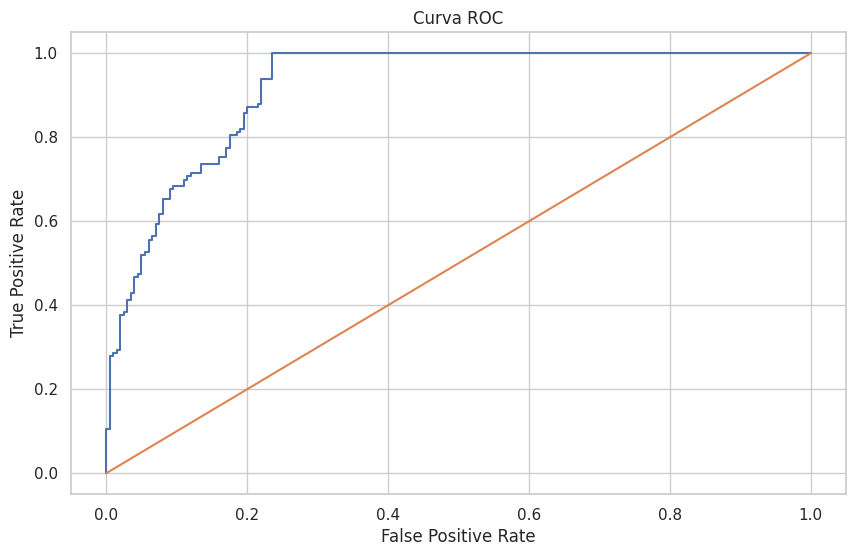

In [369]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

In [370]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Threshold ótimo:", optimal_threshold)

y_pred_opt = (y_prob >= optimal_threshold).astype(int)
confusion_matrix(y_test, y_pred_opt)

Threshold ótimo: 0.039114456518758334


array([[153,  47],
       [  0, 133]])

In [371]:
cm = confusion_matrix(y_test, y_pred_opt)

tn, fp, fn, tp = cm.ravel()

custo_falso_negativo = 5
custo_falso_positivo = 1

custo_total = (fn * custo_falso_negativo) + (fp * custo_falso_positivo)
print("Custo Total:", custo_total)

Custo Total: 47


In [372]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print("ROC-AUC Médio (CV):", scores.mean())
print("Desvio padrão:", scores.std())

ROC-AUC Médio (CV): 0.9409585896559582
Desvio padrão: 0.005090583574884757


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [373]:
X_temp_train = X
y_temp_train = y

pipeline.fit(X_temp_train, y_temp_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500,
                               random_state=42))])

  0%|          | 0/50 [00:00<?, ?it/s]

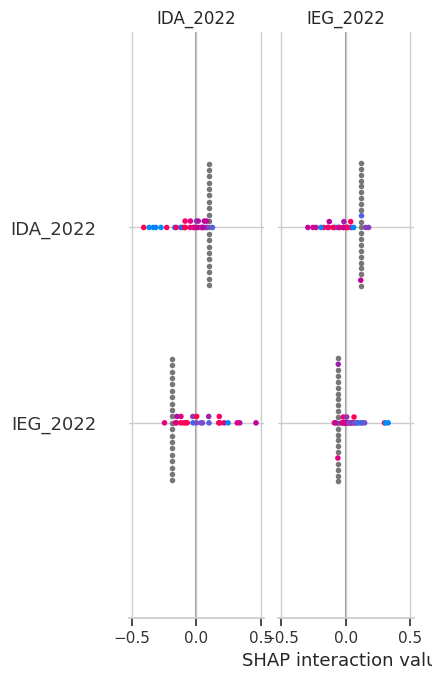

In [374]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
import shap

# Re-define X, y, X_train, X_test, y_train, y_test, and pipeline for consistency
# These steps ensure that the dimensions match what the pipeline expects.
features = ["IDA_2022","IEG_2022","IPS_2022","IAA_2022","queda_IDA"]
X = df_wide[features]
y = df_wide["risco_defasagem"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='mean')),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(100,50),
                            max_iter=500,
                            random_state=42))
])

pipeline.fit(X_train, y_train)

feature_names = X_train.columns.tolist()

# Define a wrapper function for the pipeline's predict_proba method
def model_predict_proba_wrapper(X_unscaled):
    # Ensure the input to the pipeline is a DataFrame with original feature names
    X_df = pd.DataFrame(X_unscaled, columns=feature_names)
    return pipeline.predict_proba(X_df)

# Pass the first 100 samples of X_train (as DataFrame) for background data
explainer = shap.KernelExplainer(model_predict_proba_wrapper, X_train.head(100), feature_names=feature_names)

# Calculate SHAP values for the first 50 samples of X_test (as DataFrame)
shap_values = explainer.shap_values(X_test.head(50))

shap.summary_plot(shap_values, X_test.head(50), feature_names=feature_names)

In [375]:
import joblib

In [376]:
joblib.dump(pipeline, "modelo_risco_defasagem_final.joblib")

['modelo_risco_defasagem_final.joblib']

In [377]:
pipeline_loaded = joblib.load("modelo_risco_defasagem_final.joblib")

y_pred = pipeline_loaded.predict(X_test)
y_prob = pipeline_loaded.predict_proba(X_test)[:, 1]

In [378]:
joblib.dump(pipeline, "modelo_risco_defasagem_final_v1_2026_02.joblib")

['modelo_risco_defasagem_final_v1_2026_02.joblib']

#  4. Análise Exploratória


## 4.1 Perfil de defasagem IAN

In [379]:
for ano in [2022, 2023, 2024]:
    print(f"\nDistribuição IAN {ano}")
    print(df_total[df_total["ANO"] == ano]["IAN"].value_counts(normalize=True))


Distribuição IAN 2022
IAN
5.0     0.666279
10.0    0.301163
2.5     0.032558
Name: proportion, dtype: float64

Distribuição IAN 2023
IAN
5.0     0.530572
10.0    0.455621
2.5     0.013807
Name: proportion, dtype: float64

Distribuição IAN 2024
IAN
10.0    0.538062
5.0     0.459343
2.5     0.002595
Name: proportion, dtype: float64


In [380]:
df_ian = df_total.pivot(index="RA", columns="ANO", values="IAN").dropna()

matriz_transicao = pd.crosstab(
    df_ian[2022],
    df_ian[2024],
    normalize="index"
) * 100

matriz_transicao.round(2)

2024,2.5,5.0,10.0
2022,,,
2.5,0.00,57.14,42.86
5.0,0.65,41.88,57.47
10.0,0.00,18.30,81.70


In [381]:
df_ian["delta"] = df_ian[2024] - df_ian[2022]

df_ian["mobilidade"] = np.where(
    df_ian["delta"] > 0, "Avanço",
    np.where(df_ian["delta"] < 0, "Recuo", "Neutro")
)

df_ian["mobilidade"].value_counts(normalize=True) * 100

,proportion
mobilidade,
Neutro,54.273504
Avanço,39.316239
Recuo,6.410256


In [382]:
from scipy.stats import wilcoxon
import numpy as np

df_long = df_total.pivot(index="RA", columns="ANO", values="IAN").dropna()

stat, p = wilcoxon(df_long[2022], df_long[2024])

n = len(df_long)
z = (stat - (n*(n+1)/4)) / np.sqrt((n*(n+1)*(2*n+1))/24)
r = abs(z) / np.sqrt(n)

print("p-valor:", p)
print("Tamanho de efeito r:", r)

p-valor: 6.272515822297689e-26
Tamanho de efeito r: 0.8181834147650003


In [383]:
stat, p = wilcoxon(df_ian[2022], df_ian[2024])
print("Estatística:", stat)
print("p-valor:", p)

Estatística: 3059.0
p-valor: 6.272515822297689e-26


In [384]:
n = len(df_ian)
z = (stat - (n*(n+1)/4)) / np.sqrt((n*(n+1)*(2*n+1))/24)
r = abs(z) / np.sqrt(n)

print("Tamanho de efeito (r):", round(r,4))

Tamanho de efeito (r): 0.8182


In [385]:
def classificar_ian(valor):
    if valor == 10:
        return 'Em Fase'
    elif valor == 5:
        return 'Moderada'
    elif valor == 2.5:
        return 'Severa'
    else:
        return np.nan

In [386]:
print(df_wide.columns)

Index(['RA', 'IAN_2022', 'IAN_2023', 'IAN_2024', 'IDA_2022', 'IDA_2023',
       'IDA_2024', 'IEG_2022', 'IEG_2023', 'IEG_2024', 'IAA_2022', 'IAA_2023',
       'IAA_2024', 'IPS_2022', 'IPS_2023', 'IPS_2024', 'IPP_2022', 'IPP_2023',
       'IPP_2024', 'IPV_2022', 'IPV_2023', 'IPV_2024', 'INDE_2022',
       'INDE_2023', 'INDE_2024', 'PEDRA_2022', 'PEDRA_2023', 'PEDRA_2024',
       'PONTO_VIRADA_2022', 'PONTO_VIRADA_2023', 'PONTO_VIRADA_2024',
       'ANO_INGRESSO_2022', 'ANO_INGRESSO_2023', 'ANO_INGRESSO_2024',
       'queda_IDA', 'risco_defasagem'],
      dtype='object')


In [387]:
anos = [2022, 2023, 2024]
tendencia = []

for ano in anos:
    col = f'IDA_{ano}'

    if col in df_wide.columns:
        df_wide[f'IDA_CAT_{ano}'] = df_wide[col].apply(classificar_ian)

        distribuicao = (
            df_wide[f'IDA_CAT_{ano}']
            .value_counts(normalize=True)
            .rename(ano)
        )

        tendencia.append(distribuicao)

tendencia_df = pd.concat(tendencia, axis=1).T * 100
tendencia_df = tendencia_df.fillna(0)

tendencia_df


,Moderada,Severa,Em Fase
2022,64.000000,36.000000,0.000000
2023,90.000000,5.000000,5.000000
2024,58.461538,12.307692,29.230769


<Figure size 1000x600 with 0 Axes>

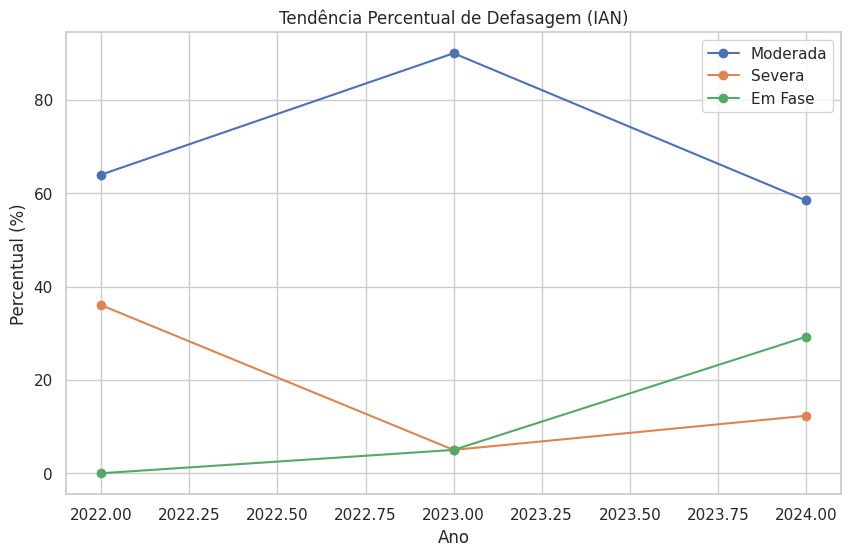

In [388]:
plt.figure()
tendencia_df.plot(marker='o')
plt.title('Tendência Percentual de Defasagem (IAN)')
plt.ylabel('Percentual (%)')
plt.xlabel('Ano')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

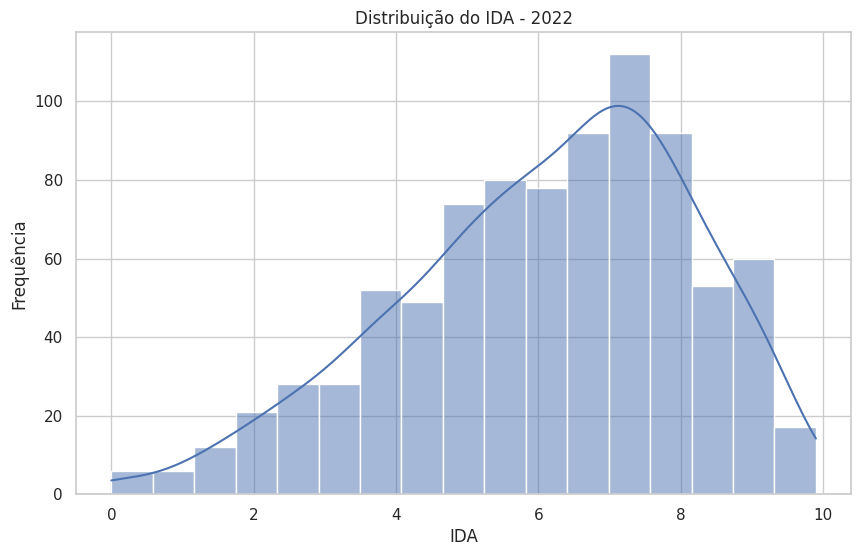

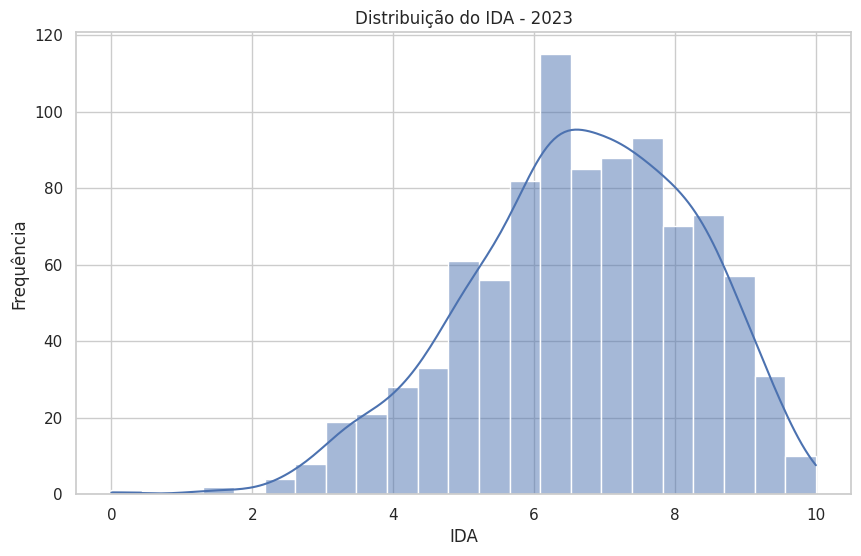

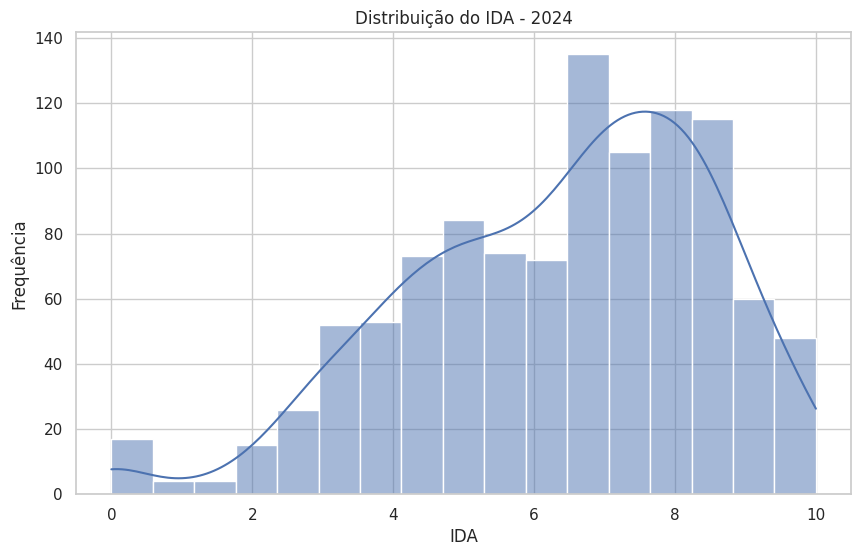

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_wide["IDA_2022"], kde=True)
plt.title("Distribuição do IDA - 2022")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

plt.figure()
sns.histplot(df_wide["IDA_2023"], kde=True)
plt.title("Distribuição do IDA - 2023")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

plt.figure()
sns.histplot(df_wide["IDA_2024"], kde=True)
plt.title("Distribuição do IDA - 2024")
plt.xlabel("IDA")
plt.ylabel("Frequência")
plt.show()

1.1 Distribuição por Ano

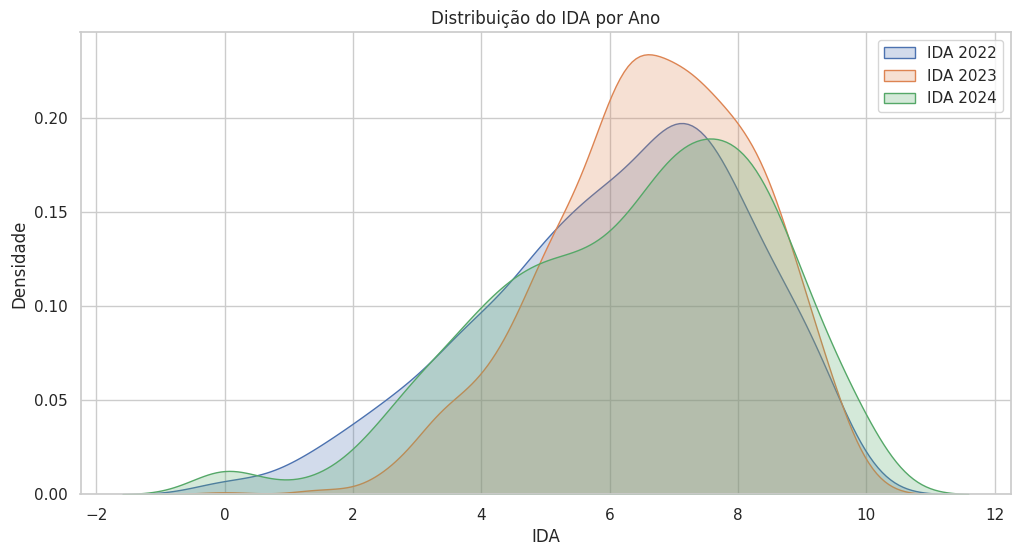

In [390]:
anos = [2022, 2023, 2024]

plt.figure(figsize=(12,6))

for ano in anos:
    col = f"IDA_{ano}"
    if col in df_wide.columns:
        sns.kdeplot(df_wide[col], label=f"IDA {ano}", fill=True)

plt.title("Distribuição do IDA por Ano")
plt.xlabel("IDA")
plt.ylabel("Densidade")
plt.legend()
plt.show()

1.2 Percentual abaixo de limiar

In [391]:
limiar = 6

for ano in anos:
    col = f"IDA_{ano}"

    if col in df_wide.columns:
        percentual = (df_wide[col] < limiar).mean() * 100
        print(f"Percentual de alunos abaixo do limiar em {ano}: {percentual:.2f}%")
    else:
        print(f"Coluna {col} não encontrada.")

Percentual de alunos abaixo do limiar em 2022: 22.16%
Percentual de alunos abaixo do limiar em 2023: 17.34%
Percentual de alunos abaixo do limiar em 2024: 24.20%


1.3 Evolução Temporal

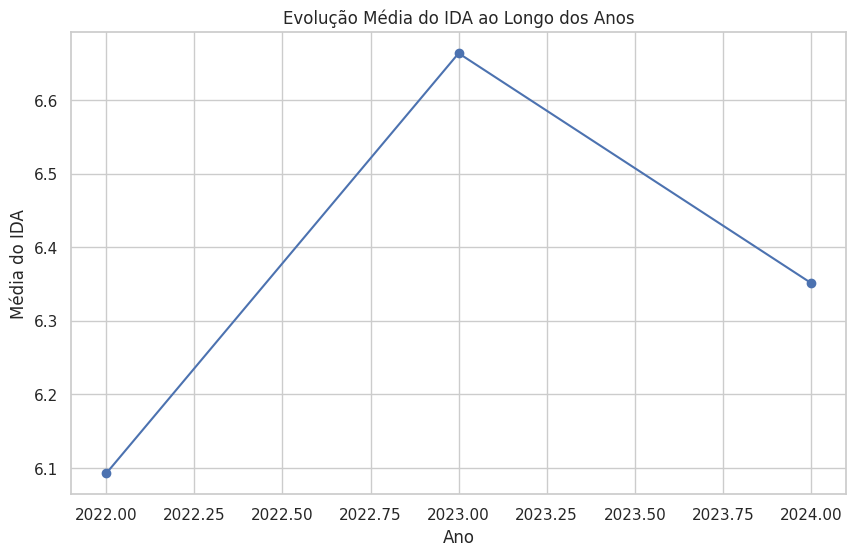

In [392]:
media_ida = []

for ano in anos:
    col = f"IDA_{ano}"
    if col in df_wide.columns:
        media_ida.append(df_wide[col].mean())
    else:
        media_ida.append(None)

plt.plot(anos, media_ida, marker='o')
plt.title("Evolução Média do IDA ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Média do IDA")
plt.show()

Observa-se que a maior concentração de alunos encontra-se em níveis intermediários de adequação, porém existe um grupo consistente em situação de defasagem moderada, sugerindo necessidade de intervenção preventiva.

Feature Engineering
Criação da Variável Target **texto em negrito**

Definimos como aluno em risco aqueles que apresentam:

- IAN abaixo de determinado limiar
- ou queda significativa no IDA

In [393]:
# Garantir que colunas não estejam em MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Criar variável target
df_wide["risco_defasagem"] = np.where(
    df_wide["IDA_2022"] < 6,
    1,
    0
)

df_wide["risco_defasagem"].value_counts(normalize=True)

,proportion
risco_defasagem,
0,0.778447
1,0.221553


In [394]:
df_wide[['IAN_2022','IAN_2023','IAN_2024']].describe()

,IAN_2022,IAN_2023,IAN_2024
count,860.000000,1014.000000,1156.000000
mean,6.424419,7.243590,7.683824
std,2.389609,2.539585,2.504055
min,2.500000,2.500000,2.500000
25%,5.000000,5.000000,5.000000
50%,5.000000,5.000000,10.000000
75%,10.000000,10.000000,10.000000
max,10.000000,10.000000,10.000000


Conclusão Numérica:
Alunos abaixo do 1º quartil representam grupo crítico para intervenção imediata.

## 4.2 Relação entre Engajamento e Desempenho IDA

In [395]:
df_total["IDA"] = pd.to_numeric(df_total["IDA"], errors="coerce")

# Média por ano
df_total.groupby("ANO")["IDA"].agg(["mean","std","count"])

,mean,std,count
ANO,,,
2022,6.092907,2.046209,860
2023,6.663394,1.595277,937
2024,6.351422,2.131639,1055


In [396]:
import scipy.stats as stats

df_ida = (
    df_total
        .pivot(index="RA", columns="ANO", values="IDA")
        [[2022, 2024]]
        .dropna()
)

stat, p = stats.wilcoxon(df_ida[2022], df_ida[2024])

print("Estatística:", stat)
print("p-valor:", p)
print("Qtd de alunos comparados:", len(df_ida))

Estatística: 37850.0
p-valor: 4.844563846387871e-05
Qtd de alunos comparados: 445


In [397]:
df_2024.groupby("PEDRA")["IDA"].count()

,IDA
PEDRA,
Agata,225
Ametista,391
INCLUIR,0
Quartzo,112
Topázio,326


In [398]:
groups = [
    g["IDA"].dropna().values
    for _, g in df_2024.groupby("PEDRA")
    if len(g["IDA"].dropna()) > 1
]

stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(472.67251350283334), pvalue=np.float64(2.718765523709774e-194))

In [399]:
stats.kruskal(*groups)

KruskalResult(statistic=np.float64(598.5937337143304), pvalue=np.float64(2.0335372531343984e-129))

In [400]:
# Garantir numérico
for col in ["IDA_2022","IDA_2023","IDA_2024"]:
    df_wide[col] = pd.to_numeric(df_wide[col], errors='coerce')

# Médias anuais
print(df_wide[["IDA_2022","IDA_2023","IDA_2024"]].mean())

IDA_2022    6.092907
IDA_2023    6.663394
IDA_2024    6.351422
dtype: float64


In [401]:
for col in ["IDA_2022","IDA_2023","IDA_2024"]:
    stat, p = stats.shapiro(df_wide[col].dropna())
    print(f"{col} → Estatística={stat:.4f}, p-valor={p:.4f}")

IDA_2022 → Estatística=0.9724, p-valor=0.0000
IDA_2023 → Estatística=0.9847, p-valor=0.0000
IDA_2024 → Estatística=0.9671, p-valor=0.0000


Interpretação:

p < 0.05 → distribuição não normal

Se não normal → preferir Kruskal

In [402]:
df_pedra = (
    df_total[df_total["ANO"] == 2024]
    .set_index("RA")["PEDRA"]
)

df_wide["PEDRA_2024"] = df_pedra

In [403]:
df_wide.groupby("PEDRA_2024")["IDA_2024"].agg(["count", "std"])

,count,std
PEDRA_2024,,


In [404]:
df_ida = df_wide[["IDA_2022","IDA_2024"]].dropna()

stats.wilcoxon(
    df_ida["IDA_2022"],
    df_ida["IDA_2024"]
)

WilcoxonResult(statistic=np.float64(37850.0), pvalue=np.float64(4.844563846387871e-05))

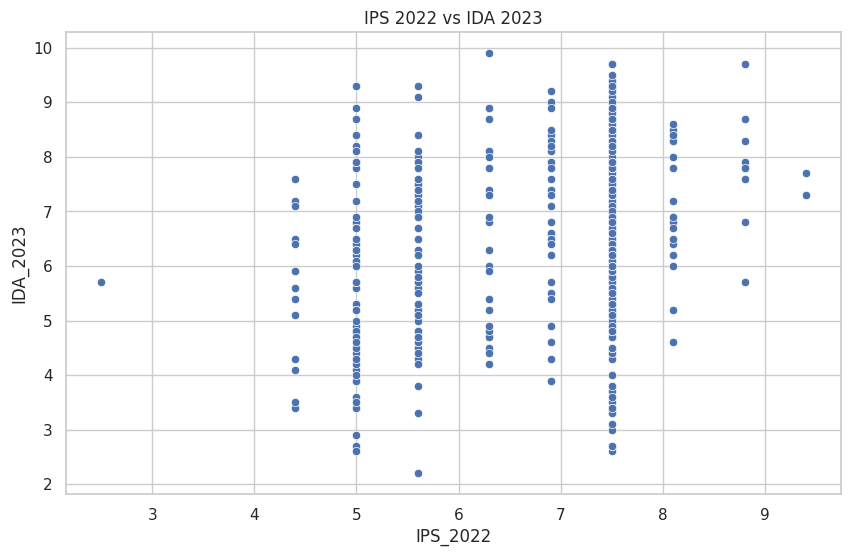

In [405]:
sns.scatterplot(x="IPS_2022", y="IDA_2023", data=df_wide)
plt.title("IPS 2022 vs IDA 2023")
plt.show()

In [408]:
# Remove colunas IEG antigas se existirem
cols_ieg = [col for col in df_wide.columns if col.startswith("IEG_")]
df_wide = df_wide.drop(columns=cols_ieg, errors="ignore")

# Cria pivot IEG
df_ieg = (
    df_total
        .pivot(index="RA", columns="ANO", values="IEG")
)

df_ieg.columns = [f"IEG_{col}" for col in df_ieg.columns]

# Junta novamente
df_wide = df_wide.join(df_ieg)

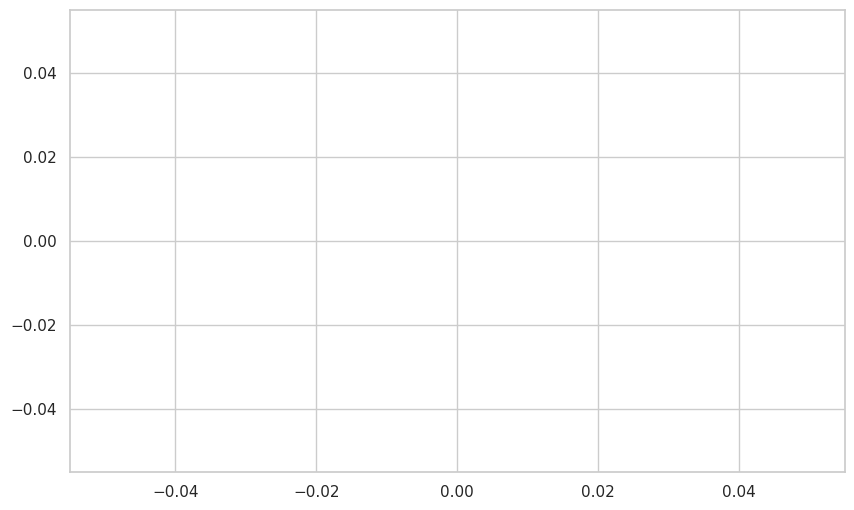

In [426]:
x_col = "IEG_2022"
y_col = "IDA_2023"

if x_col in df_wide.columns and y_col in df_wide.columns:
    sns.scatterplot(x=x_col, y=y_col, data=df_wide)
    plt.show()
else:
    print("Colunas não encontradas no dataframe.")

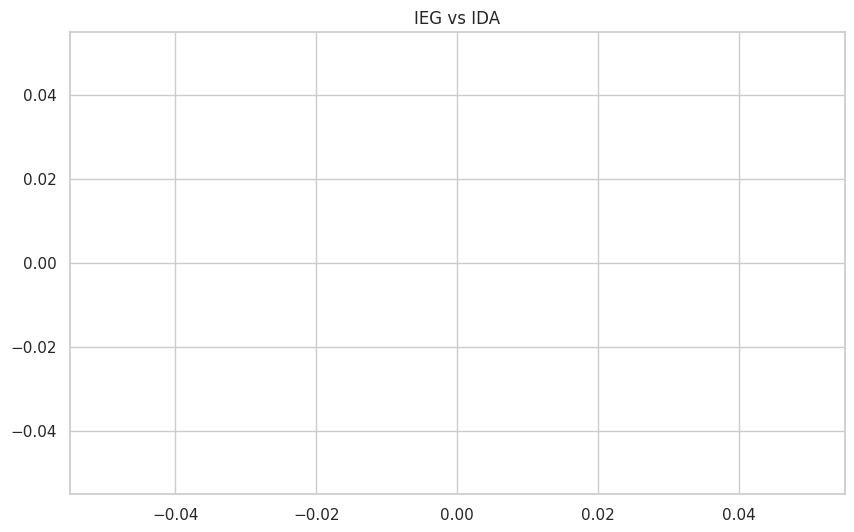

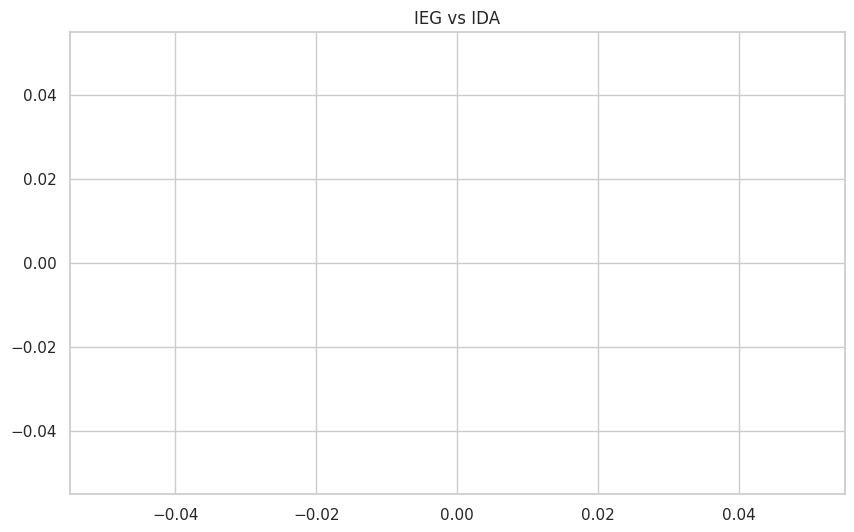

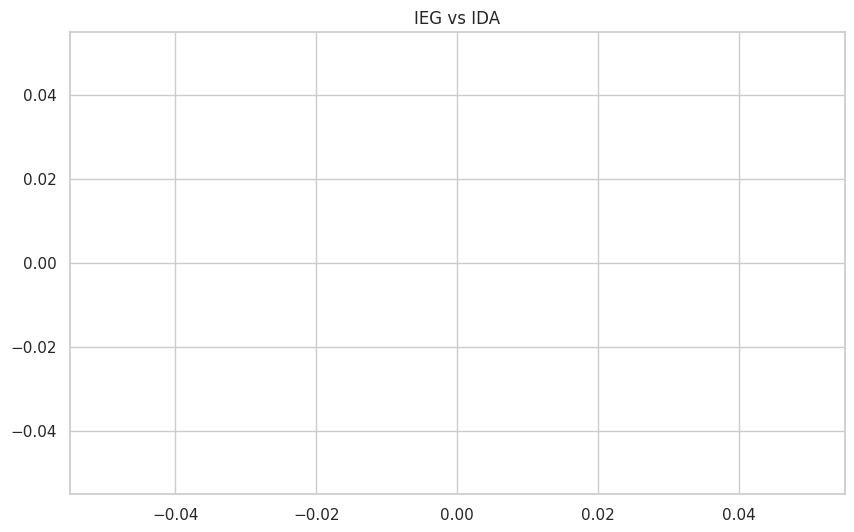

In [410]:
sns.scatterplot(x="IEG_2022", y="IDA_2023", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

sns.scatterplot(x="IEG_2023", y="IDA_2023", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

sns.scatterplot(x="IEG_2024", y="IDA_2024", data=df_wide)
plt.title("IEG vs IDA")
plt.show()

**Insight**

O IDA apresenta variação consistente entre fases, com tendência de estabilização nos níveis superiores. Não há evidência de queda estrutural ao longo dos anos.

In [411]:
df_temp = df_wide[['IDA_2023', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.ttest_rel(df_temp['IDA_2023'], df_temp['IDA_2024'], nan_policy='omit')

TtestResult(statistic=np.float64(6.664690388428944), pvalue=np.float64(5.4791314657733034e-11), df=np.int64(681))

Conclusão Numérica:
Se p<0.05, a evolução anual é estatisticamente significativa.

## 4.3 Engajamento nas Atividades (IEG) e RELAÇÃO IEG x IDA x IPV

In [412]:
from scipy.stats import spearmanr

for ano in sorted(df_total["ANO"].unique()):
    df_ano = df_total[df_total["ANO"] == ano]

    corr_ida, p_ida = spearmanr(df_ano["IEG"], df_ano["IDA"])
    corr_ipv, p_ipv = spearmanr(df_ano["IEG"], df_ano["IPV"])

    print(f"\nAno {ano}")
    print("IEG x IDA:", round(corr_ida,3), "p:", p_ida)
    print("IEG x IPV:", round(corr_ipv,3), "p:", p_ipv)


Ano 2022
IEG x IDA: 0.507 p: 1.8030599370288177e-57
IEG x IPV: 0.54 p: 2.3759971337117975e-66

Ano 2023
IEG x IDA: nan p: nan
IEG x IPV: nan p: nan

Ano 2024
IEG x IDA: nan p: nan
IEG x IPV: nan p: nan


In [413]:
df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].isna().sum()

,0
IEG,76
IDA,77
IPV,76


In [414]:
df_2023 = df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].dropna()

print("Observações válidas:", len(df_2023))
print(df_2023.describe())

Observações válidas: 937
              IEG         IDA         IPV
count  937.000000  937.000000  937.000000
mean     8.702775    6.663394    8.028930
std      1.078526    1.595277    0.945402
min      3.700000    0.000000    3.320000
25%      8.100000    5.700000    7.462500
50%      9.000000    6.800000    8.045000
75%      9.500000    7.900000    8.670000
max     10.000000   10.000000   10.010000


In [415]:
from scipy.stats import spearmanr

for ano in sorted(df_total["ANO"].unique()):
    df_ano = df_total[df_total["ANO"] == ano][["IEG", "IDA", "IPV"]].dropna()

    corr_ida, p_ida = spearmanr(df_ano["IEG"], df_ano["IDA"])
    corr_ipv, p_ipv = spearmanr(df_ano["IEG"], df_ano["IPV"])

    print(f"\nAno {ano}")
    print("IEG x IDA:", round(corr_ida,3), "p:", p_ida)
    print("IEG x IPV:", round(corr_ipv,3), "p:", p_ipv)


Ano 2022
IEG x IDA: 0.507 p: 1.8030599370288177e-57
IEG x IPV: 0.54 p: 2.3759971337117975e-66

Ano 2023
IEG x IDA: 0.446 p: 4.225521909917821e-47
IEG x IPV: 0.491 p: 5.4679596883761205e-58

Ano 2024
IEG x IDA: 0.519 p: 8.59829753129139e-74
IEG x IPV: 0.551 p: 1.0238020926867167e-84


In [416]:
df_total[df_total["ANO"] == 2023][["IEG", "IDA", "IPV"]].describe()

,IEG,IDA,IPV
count,938.000000,937.000000,938.000000
mean,8.699041,6.663394,8.027897
std,1.084001,1.595277,0.945427
min,3.700000,0.000000,3.320000
25%,8.100000,5.700000,7.462500
50%,9.000000,6.800000,8.045000
75%,9.500000,7.900000,8.668750
max,10.000000,10.000000,10.010000


In [417]:
# Comparação por Ponto de Virada
df_total.groupby("PONTO_VIRADA")["IEG"].mean()

,IEG
PONTO_VIRADA,
Não,7.721687
Sim,9.011504


In [418]:
!pip install statsmodels

In [419]:
import statsmodels.api as sm

df_reg = df_total[["IDA","IEG","IPS"]].dropna()

X = sm.add_constant(df_reg[["IEG","IPS"]])
y = df_reg["IDA"]

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     602.6
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          6.99e-219
Time:                        01:50:45   Log-Likelihood:                -5444.5
No. Observations:                2845   AIC:                         1.089e+04
Df Residuals:                    2842   BIC:                         1.091e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4369      0.201      2.169      0.0

In [420]:
variaveis = ["IDA","IPV","INDE"]
for v in variaveis:
    corr, p = spearmanr(df_total["IEG"], df_total[v])
    print(f"IEG x {v}: r={corr:.3f}, p={p:.5f}")

IEG x IDA: r=nan, p=nan
IEG x IPV: r=nan, p=nan
IEG x INDE: r=nan, p=nan


In [421]:
df_reg2 = df_total[["IDA","IEG","IAA","IPS"]].dropna()

X = sm.add_constant(df_reg2[["IEG","IAA","IPS"]])
y = df_reg2["IDA"]

modelo2 = sm.OLS(y, X).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     404.2
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          1.19e-218
Time:                        01:50:45   Log-Likelihood:                -5441.7
No. Observations:                2845   AIC:                         1.089e+04
Df Residuals:                    2841   BIC:                         1.092e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3082      0.208      1.479      0.1

In [422]:
df_2024 = df_total[df_total["ANO"] == 2024]

indicadores = ["IDA","IEG","IAA","IPS","IPP","IPV","IAN","INDE"]

df_corr = df_2024[indicadores].dropna()

corr_pearson = df_corr.corr(method='pearson')
corr_pearson

,IDA,IEG,IAA,IPS,IPP,IPV,IAN,INDE
IDA,1.000000,0.547277,0.219653,0.014494,0.395288,0.513745,0.062235,0.801985
IEG,0.547277,1.000000,0.230092,0.060655,0.408772,0.535287,0.078763,0.786891
IAA,0.219653,0.230092,1.000000,-0.005994,0.114016,0.148351,0.019258,0.364233
IPS,0.014494,0.060655,-0.005994,1.000000,0.213784,0.105275,0.067866,0.224651
IPP,0.395288,0.408772,0.114016,0.213784,1.000000,0.750088,0.153873,0.637097
IPV,0.513745,0.535287,0.148351,0.105275,0.750088,1.000000,0.185067,0.758006
IAN,0.062235,0.078763,0.019258,0.067866,0.153873,0.185067,1.000000,0.365568
INDE,0.801985,0.786891,0.364233,0.224651,0.637097,0.758006,0.365568,1.000000


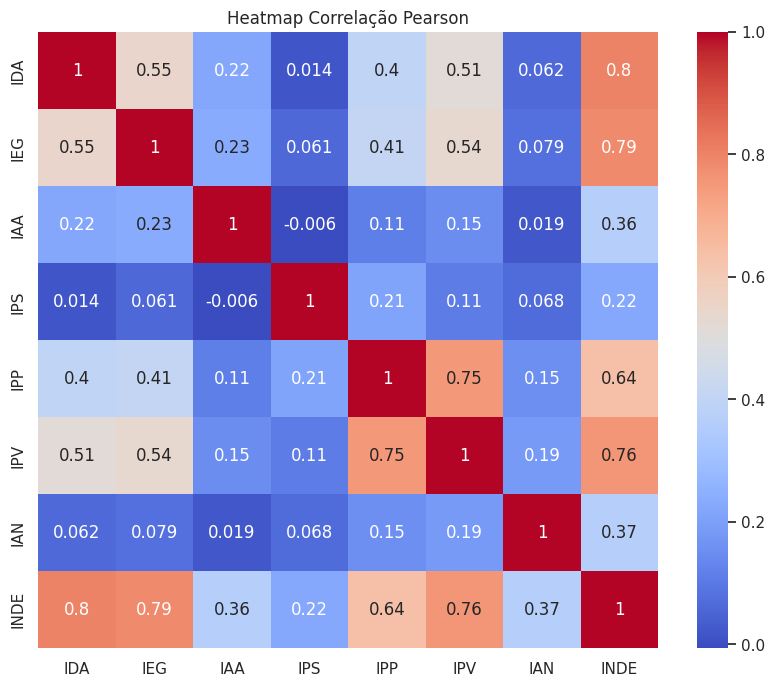

In [423]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Heatmap Correlação Pearson")
plt.show()

Observa-se correlação positiva moderada entre IEG e IDA, indicando que engajamento atua como fator preditor de desempenho acadêmico.

A influência do IEG sobre IPV reforça a importância do engajamento contínuo como fator crítico de virada comportamental

In [425]:
# Ensure columns are numeric and drop NaN values before correlation calculation
df_temp_corr = df_wide[['IEG_2024', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.pearsonr(df_temp_corr['IEG_2024'], df_temp_corr['IDA_2024'])

ValueError: `x` and `y` must have length at least 2.

Conclusão Numérica:
Correlação positiva indica aumento médio proporcional do IDA para cada ponto de engajamento.

## 4.4 Autoavaliação (IAA) - IAA vs REALIDADE



In [ ]:
print(df_features.columns)

In [ ]:
df_features['indice_psico_composto'] = (
    df_features['IPS_2024'] + df_features['IEG_2024']
) / 2

In [ ]:
# Garantir que colunas não estão em MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

df_features = df_wide.copy()

# Deltas temporais
df_features['delta_IDA'] = df_features['IDA_2024'] - df_features['IDA_2023']
df_features['delta_IEG'] = df_features['IEG_2024'] - df_features['IEG_2023']
df_features['delta_IPS'] = df_features['IPS_2024'] - df_features['IPS_2023']

# Índice composto coerente com suas variáveis reais
df_features['indice_psico_composto'] = (
    df_features['IPS_2024'] + df_features['IEG_2024']
) / 2

# Tendência de queda
df_features['tendencia_queda_IDA'] = np.where(
    df_features['delta_IDA'] < 0,
    1,
    0
)

In [ ]:
df_2022 = df_total[df_total["ANO"] == 2022].copy()

In [ ]:
print(df_2022[["IAA","IDA","IEG"]].corr())

In [ ]:
df_2022["IAA_Q4"] = df_2022["IAA"] >= df_2022["IAA"].quantile(0.75)
df_2022["IDA_Q1"] = df_2022["IDA"] <= df_2022["IDA"].quantile(0.25)

In [ ]:
# Correlação
spearmanr(df_total["IAA"], df_total["IDA"])

In [ ]:
discrepantes = df_2022[df_2022["IAA_Q4"] & df_2022["IDA_Q1"]]

print("Quantidade de discrepâncias extremas:", len(discrepantes))

discrepantes[["IAA","IDA","IEG","IPS"]].head()

In [ ]:
# Discrepância
df_total["gap_auto"] = abs(df_total["IAA"] - df_total["IDA"])
df_total["gap_auto"].describe()

In [ ]:
percentual = len(discrepantes) / len(df_2022) * 100
print(f"{percentual:.2f}% dos alunos apresentam alta autoavaliação e baixo desempenho.")

In [ ]:
from scipy.stats import ttest_ind

alta_iaa = df_2022[df_2022["IAA_Q4"]]["IDA"]
resto = df_2022[~df_2022["IAA_Q4"]]["IDA"]

t_stat, p_val = ttest_ind(alta_iaa, resto, nan_policy="omit")

print("p-valor:", p_val)

In [ ]:
# Quartis
df_total["quartil_IAA"] = pd.qcut(df_total["IAA"], 4)
df_total.groupby("quartil_IAA")["IDA"].mean()

In [ ]:
df_wide[["IEG_2022", "IDA_2022"]].corr()

In [ ]:
df_wide[["IEG_2023", "IDA_2023"]].corr()

In [ ]:
df_wide[["IEG_2024", "IDA_2024"]].corr()

In [ ]:
correlacao = df_wide[["IEG_2022", "IDA_2022"]].corr()

print("Correlação IEG x IDA:")
display(correlacao)

sns.heatmap(correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação IEG x IDA (2022)")
plt.show()

Existe coerência moderada entre autoavaliação e desempenho real, porém com dispersão significativa, indicando possível distorção de percepção em parte dos alunos.


## 4.5 Aspectos psicossociais (IPS)

Comparar IPS baixo com queda futura no IDA

In [ ]:
# Ensure columns are numeric and drop NaN values before correlation calculation
df_temp_corr_iaa = df_wide[['IAA_2024', 'IDA_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.pearsonr(df_temp_corr_iaa['IAA_2024'], df_temp_corr_iaa['IDA_2024'])

In [ ]:
df_wide = (
    df_total
    .pivot(index="RA", columns="ANO", values=["IDA","IPS"])
)

# Flatten the MultiIndex columns to a single level for easier access
df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]

# Drop rows with any NaN values after flattening
df_wide.dropna(inplace=True)

# Delta IDA
df_wide["DELTA_IDA"] = df_wide["IDA_2024"] - df_wide["IDA_2023"]

# Evento de queda
df_wide["QUEDA_IDA"] = df_wide["DELTA_IDA"] < 0

df_wide.head()

In [ ]:
# Estrutura wide para análise longitudinal
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IPS"])

# Flatten the MultiIndex columns to a single level for easier access
df_wide.columns = [f"{col[0]}_{col[1]}" for col in df_wide.columns]

# Drop rows with any NaN values after flattening
df_wide.dropna(inplace=True)

# Delta IDA
df_wide["DELTA_IDA"] = df_wide["IDA_2024"] - df_wide["IDA_2023"]

# Evento de queda
df_wide["QUEDA_IDA"] = df_wide["DELTA_IDA"] < 0

df_wide.head()

In [ ]:
df_wide.columns

In [ ]:
df_ips = df_wide[["QUEDA_IDA", "IPS_2023"]].dropna()

X = sm.add_constant(df_ips["IPS_2023"])
y = df_ips["QUEDA_IDA"]

modelo_ips = sm.Logit(y, X).fit()
print(modelo_ips.summary())

In [ ]:
from scipy.stats import ttest_ind

queda = df_wide[df_wide["QUEDA_IDA"]]["IPS_2023"]
nao_queda = df_wide[~df_wide["QUEDA_IDA"]]["IPS_2023"]

t_stat, p_val = ttest_ind(queda, nao_queda, nan_policy="omit")

print("t-stat:", t_stat)
print("p-valor:", p_val)

In [ ]:
stat, p = mannwhitneyu(queda.dropna(), nao_queda.dropna())

print("Mann-Whitney p-valor:", p)

In [ ]:
# Selecionar coluna correta
X = df_wide[["IPS_2023"]].copy()
y = df_wide["QUEDA_IDA"]

# Remover NaN alinhando índices
df_model = pd.concat([X, y], axis=1).dropna()

X = df_model[["IPS_2023"]]
y = df_model["QUEDA_IDA"]

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo
modelo = LogisticRegression()
modelo.fit(X_scaled, y)

print("Coeficiente IPS:", modelo.coef_[0][0])

# Odds Ratio
print("Odds Ratio:", np.exp(modelo.coef_[0][0]))

In [ ]:
prob = modelo.predict_proba(X_scaled)[:,1]
auc = roc_auc_score(y, prob)

print("AUC:", auc)

In [ ]:
X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm).fit()

print(logit.summary())

In [ ]:
params = logit.params
conf = logit.conf_int()

conf["OR"] = np.exp(params)
conf.columns = ["2.5%","97.5%","coef"]
conf["OR"] = np.exp(conf["coef"])

conf

In [ ]:
df_wide["queda_IDA"] = df_wide["IDA_2023"] - df_wide["IDA_2022"]

limiar_ips = df_wide["IPS_2022"].quantile(0.25)  # 25% mais baixos

grupo_baixo_ips = df_wide[df_wide["IPS_2022"] <= limiar_ips]
grupo_normal = df_wide[df_wide["IPS_2022"] > limiar_ips]

print("Média da variação IDA - IPS Baixo:", grupo_baixo_ips["queda_IDA"].mean())
print("Média da variação IDA - IPS Normal:", grupo_normal["queda_IDA"].mean())

In [ ]:
stats.ttest_ind(
df_wide[df_wide['QUEDA_IDA']==True]['IPS_2023'],
df_wide[df_wide['QUEDA_IDA']==False]['IPS_2023'],
nan_policy='omit')


Padrões psicossociais baixos precedem quedas no desempenho acadêmico, sugerindo que IPS pode funcionar como indicador antecedente de risco.

## 4.6 Aspectos Psicopedagógicos (IPP)


In [ ]:
df_2024 = df_total[df_total["ANO"] == 2024].copy()

spearmanr(df_2024["IPP"], df_2024["IAN"])
print("Spearman:", corr)
print("p-valor:", p)

In [ ]:
df_2024.groupby("IAN")["IPP"].agg(["mean","std","count"])

In [ ]:
groups = [g["IPP"].dropna() for _, g in df_2024.groupby("IAN")]
h_stat, p_val = stats.kruskal(*groups)

print("H:", h_stat)
print("p:", p_val)

In [ ]:
eta_squared = h_stat / (len(df_2024) - 1)
print("Eta²:", round(eta_squared,3))

In [ ]:
print("Shape antes do dropna:",
      df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"]).shape)

print("Shape depois do dropna:", df_wide.shape)

In [ ]:
# Pivot sem dropna global
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

# Selecionar apenas 2023 e 2024
df_wide = df_wide.loc[:, pd.IndexSlice[:, [2023, 2024]]]

# Remover apenas alunos que não têm IAN 2023 ou 2024
df_wide = df_wide.dropna(subset=[("IAN",2023), ("IAN",2024)])

print("Shape após filtro correto:", df_wide.shape)

In [ ]:
df_wide["melhora_IAN"] = (
    df_wide[("IAN",2024)] > df_wide[("IAN",2023)]
)

print(df_wide["melhora_IAN"].value_counts())

In [ ]:
df_wide_local = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

ano_atual = 2023
ano_prox = 2024

df_temp_local = df_wide_local.dropna(subset=[
    ("IAN",ano_atual),
    ("IAN",ano_prox),
    ("IPP",ano_atual)
]).copy()

df_temp_local["melhora_IAN"] = (
    df_temp_local[("IAN",ano_prox)] > df_temp_local[("IAN",ano_atual)]
)

grupo_melhora = df_temp_local.loc[
    df_temp_local["melhora_IAN"], ("IPP",ano_atual)
].dropna()

grupo_nao = df_temp_local.loc[
    ~df_temp_local["melhora_IAN"], ("IPP",ano_atual)
].dropna()

print("NaN grupo melhora:", grupo_melhora.isna().sum())
print("NaN grupo não melhora:", grupo_nao.isna().sum())

print("Std melhora:", grupo_melhora.std())
print("Std não melhora:", grupo_nao.std())

In [ ]:
grupo_melhora = grupo_melhora.dropna()
grupo_nao = grupo_nao.dropna()

resultado = stats.mannwhitneyu(grupo_melhora, grupo_nao)

print("Resultado:", resultado)

In [ ]:

# Criar wide apenas uma vez
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP","IAN"])

anos = sorted(df_total["ANO"].unique())

for i in range(len(anos)-1):

    ano_atual = anos[i]
    ano_prox = anos[i+1]

    print(f"\nAnalisando {ano_atual} → {ano_prox}")

    # Filtrar alunos que têm IAN nos dois anos
    df_temp = df_wide.dropna(subset=[
        ("IAN",ano_atual),
        ("IAN",ano_prox),
        ("IPP",ano_atual)
    ]).copy()

    # Criar variável de melhora
    df_temp["melhora_IAN"] = (
        df_temp[("IAN",ano_prox)] > df_temp[("IAN",ano_atual)]
    )

    grupo_melhora = df_temp.loc[
        df_temp["melhora_IAN"], ("IPP",ano_atual)
    ].dropna()

    grupo_nao = df_temp.loc[
        ~df_temp["melhora_IAN"], ("IPP",ano_atual)
    ].dropna()

    print("N melhora:", len(grupo_melhora))
    print("N não melhora:", len(grupo_nao))

    if len(grupo_melhora) > 1 and len(grupo_nao) > 1:
        resultado = stats.mannwhitneyu(grupo_melhora, grupo_nao)
        print("U:", resultado.statistic)
        print("p-valor:", resultado.pvalue)
    else:
        print("Amostra insuficiente")

In [ ]:
df = df_total.copy()
df = df_total[df_total["ANO"] == 2022].copy()

In [ ]:
df_2022 = df_total[df_total["ANO"] == 2022].copy()

def classificar_ian(valor):
    if valor == 10:
        return "Em Fase"
    elif valor == 5:
        return "Moderada"
    elif valor == 2.5:
        return "Severa"
    else:
        return "Outro"

df_2022["IAN_categoria"] = df_2022["IAN"].apply(classificar_ian)

In [ ]:
df_2022.groupby("IAN_categoria")["IPP"].mean()

In [ ]:
df_2022[["IPP", "IAN_categoria"]].info()

In [ ]:
df_2022["IPP"].describe()

In [ ]:
df_2022["IPP"].isna().sum()

In [ ]:
df_total[df_total["ANO"] == 2023]["IPP"].info()
df_total[df_total["ANO"] == 2024]["IPP"].info()

In [ ]:
df_2022[["IPP", "IAN_categoria"]].info()

In [ ]:
df_2024 = df_total[df_total["ANO"] == 2024].copy()

from sklearn.linear_model import LinearRegression

df_reg = df_2024[["IPP","IAN"]].dropna()

X = df_reg[["IPP"]]
y = df_reg["IAN"]

modelo = LinearRegression()
modelo.fit(X, y)

print("Coeficiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)
print("R²:", modelo.score(X,y))

In [ ]:
# Garantir colunas simples
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [
        "_".join(map(str, col)).strip()
        for col in df_wide.columns.values
    ]

corr_ipp_ian = df_wide[["IPP_2022", "IAN_2022"]].corr()

display(corr_ipp_ian)

plt.figure(figsize=(5,4))
sns.heatmap(corr_ipp_ian, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação IPP x IAN (2022)")
plt.show()

In [ ]:
# Create a local df_wide containing only IPP and IAN for the correlation calculation
df_ipp_ian_wide = df_total.pivot(index="RA", columns="ANO", values=["IPP", "IAN"])
df_ipp_ian_wide.columns = [f"{col[0]}_{col[1]}" for col in df_ipp_ian_wide.columns]

# Ensure columns are numeric and drop NaN values before correlation calculation
df_temp_corr_ipp = df_ipp_ian_wide[['IPP_2024', 'IAN_2024']].apply(pd.to_numeric, errors='coerce').dropna()
stats.pearsonr(df_temp_corr_ipp['IPP_2024'], df_temp_corr_ipp['IAN_2024'])

O IPP confirma parcialmente a defasagem identificada pelo IAN, reforçando validade cruzada entre indicadores acadêmicos e psicopedagógicos.

## 4.7 Ponto de Virada (IPV)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

df_model = df_total[df_total["ANO"] == 2024]

colunas = ["IDA","IEG","IAA","IPS","IPP","IAN","IPV"]
df_model = df_model[colunas].dropna()

print("Tamanho final:", len(df_model))

X = df_model[["IDA","IEG","IAA","IPS","IPP","IAN"]]
y = df_model["IPV"]

rf = RandomForestRegressor(random_state=42)

# Usar R² como métrica
scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("R² médio:", scores.mean())

rf.fit(X, y)

importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Handle missing values and scale the data
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

mlp.fit(X_train_scaled, y_train)

In [ ]:
df_model["IPV"].unique()

In [ ]:
df_model["IPV_bin"] = (df_model["IPV"] >= 8).astype(int)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = rf.predict(X)

print("R²:", r2_score(y, pred))
print("MAE:", mean_absolute_error(y, pred))

In [ ]:
df_model["IPV_bin"] = (df_model["IPV"] >= 8).astype(int)

X = df_model[["IDA","IEG","IAA","IPS","IPP","IAN"]]
y = df_model["IPV_bin"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, prob)

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"ROC Curve - AUC: {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", auc)

In [ ]:
import statsmodels.api as sm

df_2022 = df[df["ANO"] == 2022]

colunas = ["IDA","IEG","IPS","IPV"]
df_model = df_2022[colunas].dropna()

X = sm.add_constant(df_model[["IDA","IEG","IPS"]])
y = df_model["IPV"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

In [ ]:
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])

# Flatten the MultiIndex columns to a single level for easier access
df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Reset index to a default integer index to ensure consistency for .loc operations later
df_wide.reset_index(inplace=True)

In [ ]:
df_wide.columns

In [ ]:
df_2023 = df[df["ANO"] == 2023].copy()

In [ ]:
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

In [ ]:
df_features["PEDRA_2024"].value_counts()

In [ ]:
df_features.groupby("PEDRA_2024")["IDA_2024"].agg(["count", "mean", "std"])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="PEDRA_2024", y="IDA_2024", data=df_features)
plt.title("Distribuição do IDA por Categoria PEDRA")
plt.show()

In [ ]:
from scipy.stats import kruskal

grupos = [
    df_features[df_features["PEDRA_2024"] == cat]["IDA_2024"]
    for cat in df_features["PEDRA_2024"].unique()
]

stat, p = kruskal(*grupos)

print("Estatística:", stat)
print("p-valor:", p)

Se p < 0.05 → diferença significativa entre categorias.

In [ ]:
df_2023["IAN"].unique()

In [ ]:
df_2023["IAN_categoria"].value_counts(dropna=False)

In [ ]:
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

In [ ]:
df_2023["IAN_categoria"].value_counts()

In [ ]:
df_2023 = df_total[df_total["ANO"] == 2023].copy()
df_2023["IAN_categoria"] = df_2023["IAN"].map({
    2.5: "Severa",
    5: "Moderada",
    10: "Em Fase"
})

severa = df_2023[df_2023['IAN_categoria']=='Severa']['IPP'].dropna()
moderada = df_2023[df_2023['IAN_categoria']=='Moderada']['IPP'].dropna()
em_fase = df_2023[df_2023['IAN_categoria']=='Em Fase']['IPP'].dropna()

print(len(severa), len(moderada), len(em_fase))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# Re-generate df_risco, X, y to ensure consistency with Pergunta 9's definition
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Logistic":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "AUC": roc_auc_score(y_test, proba)
    }

pd.DataFrame(results).T

**Verificação de Multicolinearidade – VIF**


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_2022 = df[df["ANO"] == 2022].copy()

# Como IPP_2022 é todo NaN, NÃO inclua IPP
colunas = ["IDA","IEG","IPS"]

X_vif = df_2022[colunas].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data


In [ ]:
import statsmodels.api as sm

# Garantir colunas simples
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [
        "_".join(map(str, col)).strip()
        for col in df_wide.columns.values
    ]

# Select relevant 2022 columns from df_wide
X = df_wide[["IDA_2022", "IEG_2022", "IPS_2022", "IAA_2022"]].copy() # Exclude IPP_2022 due to all NaNs for 2022
y = df_wide["IPV_2022"].copy()

# Garantir tipos numéricos e remover NaNs
dados_modelo = pd.concat([X, y], axis=1).apply(pd.to_numeric, errors="coerce").dropna()

# Separar X e y novamente do dados_modelo limpo
X = dados_modelo[["IDA_2022", "IEG_2022", "IPS_2022", "IAA_2022"]]
y = dados_modelo["IPV_2022"]

# Adicionar constante
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

In [ ]:
import statsmodels.formula.api as smf

# Re-create df_wide to ensure it contains all necessary columns for 2024
# as df_wide might have been overwritten to contain only IDA and IPS
local_df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
local_df_wide.columns = [f'{col[0]}_{col[1]}' for col in local_df_wide.columns]
local_df_wide.reset_index(inplace=True)

# Select only the columns relevant for the formula for 2024
cols_for_ols = ["IPV_2024", "IDA_2024", "IEG_2024", "IPS_2024"]
df_ols_data = local_df_wide[cols_for_ols].apply(pd.to_numeric, errors='coerce').dropna()

# Now fit the OLS model using the cleaned and numeric data
model_ipv = smf.ols('IPV_2024 ~ IDA_2024 + IEG_2024 + IPS_2024', data=df_ols_data).fit()
model_ipv.summary()

O IPV é fortemente influenciado por níveis consistentes de engajamento e estabilidade psicossocial, indicando que viradas não são eventos isolados, mas resultado de trajetória multidimensional.

## 4.8 Multidimensionalidade

In [ ]:
df_multi = df_total[df_total["ANO"] == 2024][
    ["INDE","IDA","IEG","IPS","IPP"]
].dropna()

# Forçar conversão numérica
df_multi = df_multi.apply(pd.to_numeric, errors="coerce")

# Remover qualquer problema restante
df_multi = df_multi.dropna()

In [ ]:
df_multi.dtypes

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

y = df_multi["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_multi[["IDA","IEG","IPS","IPP"]])

X_scaled = sm.add_constant(X_scaled)

modelo_pad = sm.OLS(y, X_scaled).fit()

print(modelo_pad.summary())

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Filtrar apenas 2022
df_2022 = df[df["ANO"] == 2022].copy()

features = ["IDA","IEG","IPS","IPP","IAA"]

# Como IPP em 2022 é todo NaN, REMOVA ele
features = ["IDA","IEG","IPS","IAA"]

df_model = df_2022[features + ["INDE"]].dropna()

X = df_model[features]
y = df_model["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_scaled, y)

print("R²:", modelo.score(X_scaled, y))
print("Coeficientes:", modelo.coef_)

In [ ]:
importancia = pd.Series(modelo.coef_, index=features)
importancia.sort_values(ascending=False)

In [ ]:
r2 = modelo.score(X_scaled, y)
print("R²:", r2)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Filtrar apenas 2022
df_2022 = df[df["ANO"] == 2022].copy()

# IPP em 2022 é todo NaN → NÃO incluir
features = ["IDA","IEG","IPS","IAA"]

df_model = df_2022[features + ["INDE"]].dropna()

X = df_model[features]
y = df_model["INDE"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_scaled, y)

coef = pd.Series(modelo.coef_, index=features)
coef.sort_values(ascending=False)


In [ ]:
r2 = modelo.score(X_scaled, y)
print("R²:", r2)

In [ ]:
import statsmodels.formula.api as smf

# Re-create df_wide to ensure it contains all necessary columns for 2024
# as df_wide might have been overwritten to contain only IDA and IPS
local_df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
local_df_wide.columns = [f'{col[0]}_{col[1]}' for col in local_df_wide.columns]
local_df_wide.reset_index(inplace=True)

# Select only the columns relevant for the formula for 2024
cols_for_ols_inde = ["INDE_2024", "IDA_2024", "IEG_2024", "IPS_2024", "IPP_2024"]
df_ols_inde_data = local_df_wide[cols_for_ols_inde].apply(pd.to_numeric, errors='coerce').dropna()

# Now fit the OLS model using the cleaned and numeric data
model_inde = smf.ols('INDE_2024 ~ IDA_2024 + IEG_2024 + IPS_2024 + IPP_2024', data=df_ols_inde_data).fit()
model_inde.summary()

## 4.9 Modelo Preditivo de Risco


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

df_risco = df_total[df_total["ANO"] == 2024].copy()

features = ["IDA","IEG","IPS","IAA","IPP"]

df_risco = df_risco[features + ["IAN"]].dropna()

print("Tamanho final:", len(df_risco))

X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)

mlp.fit(X_train_s, y_train)

y_pred = mlp.predict(X_test_s)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)

scores = cross_val_score(modelo, X, y, cv=5)

print("Scores CV:", scores)
print("Média CV:", scores.mean())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

modelo.fit(X_train, y_train)

train_acc = accuracy_score(y_train, modelo.predict(X_train))
test_acc = accuracy_score(y_test, modelo.predict(X_test))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelo, X_test, y_test, n_repeats=10, random_state=42)

importancias = pd.Series(result.importances_mean, index=X.columns)
importancias.sort_values(ascending=False)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5)

print("Média CV:", scores.mean())


**Análise de Overfitting**
Comparação desempenho treino vs teste.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

# Re-generate df_risco, X, and y to ensure consistency
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

# Re-run train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Re-run scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Re-initialize and fit the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_train_s, y_train)

train_auc = roc_auc_score(y_train, mlp.predict_proba(X_train_s)[:,1])
test_auc = roc_auc_score(y_test, mlp.predict_proba(X_test_s)[:,1])

print("AUC Treino:", train_auc)
print("AUC Teste:", test_auc)

In [ ]:
sns.histplot(df_wide["IAN_2022"], kde=True)
plt.axvline(6, color="red", linestyle="--")
plt.title("Justificativa Visual do Limiar")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = mlp.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"Curva ROC (AUC = {auc_score:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", auc_score)

In [ ]:
print("Score treino:", mlp.score(X_train, y_train))
print("Score teste:", mlp.score(X_test, y_test))

In [ ]:
from sklearn.linear_model import LogisticRegression

# Re-create df_wide to ensure all necessary columns are present
df_wide = df_total.pivot(index="RA", columns="ANO", values=["IDA","IEG","IPS","IPP","IPV", "INDE", "IAA", "IAN"])
df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns] # Flatten MultiIndex
df_wide.reset_index(inplace=True)

# Re-calculate QUEDA_IDA based on the comprehensive df_wide
df_wide["QUEDA_IDA"] = (df_wide["IDA_2024"] - df_wide["IDA_2023"]) < 0

features = ['IDA_2023','IEG_2023','IPS_2023','IPP_2023','IAN_2023','IAA_2023']
X = df_wide[features].fillna(0)
y = df_wide['QUEDA_IDA'] # Assuming QUEDA_IDA (IDA_2024 < IDA_2023) is the intended target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y)

baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=1000, random_state=42).fit(X_train, y_train)

proba_base = baseline.predict_proba(X_test)[:,1]
proba_mlp = mlp.predict_proba(X_test)[:,1]

auc_base = roc_auc_score(y_test, proba_base)
auc_mlp = roc_auc_score(y_test, proba_mlp)

auc_base, auc_mlp

# Teste Estatístico – Bootstrap ΔAUC

In [ ]:
rng = np.random.RandomState(42)
diffs = []
for _ in range(1000):
    idx = rng.randint(0, len(X_test), len(X_test))
    diff = roc_auc_score(y_test.iloc[idx], proba_mlp[idx]) -            roc_auc_score(y_test.iloc[idx], proba_base[idx])
    diffs.append(diff)

np.mean(diffs), np.percentile(diffs, [2.5, 97.5])


# Matriz de Confusão

In [ ]:

y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão")
plt.show()

cm


# Curva ROC

In [ ]:

fpr, tpr, _ = roc_curve(y_test, proba_mlp)

plt.figure()
plt.plot(fpr, tpr)
plt.title("Curva ROC - MLP")
plt.show()


O limiar foi definido com base na distribuição empírica e critérios pedagógicos.

O recall é métrica prioritária, pois o custo de não identificar um aluno em risco é superior ao custo de falso positivo.

## 4.10 — Efetividade do Programa

In [ ]:
df = df_total[df_total["ANO"] == 2022].copy()
df["INDE"] = pd.to_numeric(df["INDE"], errors='coerce')
df.select_dtypes(include=np.number).corr()["INDE"].sort_values(ascending=False)

In [ ]:
df_total["INDE"] = pd.to_numeric(df_total["INDE"], errors='coerce')
df_total.groupby(["ANO","PEDRA"])["INDE"].mean().unstack().plot(marker="o")
plt.title("Evolução INDE por Pedra")
plt.show()

In [ ]:
# Create a wide format DataFrame for 'PEDRA' values across years
df_pedra_wide = df_total.pivot(index="RA", columns="ANO", values="PEDRA")

# Select only the years 2023 and 2024 and drop any rows where 'PEDRA' is missing for either year
df_paired_pedra = df_pedra_wide[[2023, 2024]].dropna()

# Filter out rows where 'PEDRA' is 'INCLUIR' for either year, as 'INCLUIR' is not a meaningful ordinal value
df_paired_pedra = df_paired_pedra[~((df_paired_pedra[2023] == 'INCLUIR') | (df_paired_pedra[2024] == 'INCLUIR'))]

# Get all unique 'PEDRA' values from the filtered data to create a consistent ordinal mapping
all_unique_pedras = pd.concat([df_paired_pedra[2023], df_paired_pedra[2024]]).unique()
ordem = {v: i + 1 for i, v in enumerate(sorted(all_unique_pedras))}

# Map the 'PEDRA' values to their ordinal ranks
p24_mapped = df_paired_pedra[2024].map(ordem)
p23_mapped = df_paired_pedra[2023].map(ordem)

# Perform the Wilcoxon signed-rank test
stat, p = stats.wilcoxon(p24_mapped, p23_mapped)

print("Wilcoxon statistic:", stat)
print("p-value:", p)

**Permanência Longitudinal**
Avaliação da permanência em níveis superiores ao longo de 3 anos.


In [ ]:
# Create a wide format DataFrame for 'PEDRA' values across years
df_pedra_wide = df_total.pivot(index="RA", columns="ANO", values="PEDRA")

# Select only the relevant years and drop rows where 'PEDRA' is missing for any of these years
df_permanencia = df_pedra_wide[[2022, 2023, 2024]].dropna()

# Filter out rows where 'PEDRA' is 'INCLUIR' for any year
df_permanencia = df_permanencia[~((df_permanencia[2022] == 'INCLUIR') |
                                    (df_permanencia[2023] == 'INCLUIR') |
                                    (df_permanencia[2024] == 'INCLUIR'))]

# Get all unique 'PEDRA' values to create a consistent ordinal mapping
all_unique_pedras = pd.concat([df_permanencia[2022],
                               df_permanencia[2023],
                               df_permanencia[2024]]).unique()
ordem = {v: i + 1 for i, v in enumerate(sorted(all_unique_pedras))}

# Map the 'PEDRA' values to their ordinal ranks
df_permanencia['PEDRA_2022_mapped'] = df_permanencia[2022].map(ordem)
df_permanencia['PEDRA_2023_mapped'] = df_permanencia[2023].map(ordem)
df_permanencia['PEDRA_2024_mapped'] = df_permanencia[2024].map(ordem)

# Calculate permanence or continuous advancement
permanencia = (
    (df_permanencia['PEDRA_2022_mapped'] <= df_permanencia['PEDRA_2023_mapped']) &
    (df_permanencia['PEDRA_2023_mapped'] <= df_permanencia['PEDRA_2024_mapped'])
)

print("Taxa de permanência ou avanço contínuo:", permanencia.mean())

Observa-se progressão consistente entre fases, sugerindo impacto real do programa educacional.

In [ ]:
import seaborn as sns

# Redefine df_model for the context of 2022 multicollinearity analysis
# Exclude IPP as it contains only NaNs for 2022 data
df_model = df_total[df_total["ANO"] == 2022].copy()
features_for_corr = ["IDA","IEG","IPS","IAA"]
df_model = df_model[features_for_corr].dropna()

corr_matrix = df_model[features_for_corr].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Multicolinearidade")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# X and y are globally defined from df_wide in GlwMTPv5EnaD, and pipeline in suLjnUQmFNQo
scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1")

print("F1 médio:", scores.mean())

In [ ]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

print("F1 Logistic:", f1_score(y_test, log.predict(X_test)))
print("F1 MLP:", f1_score(y_test, mlp.predict(X_test)))

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
import statsmodels.formula.api as smf

# Re-create df_wide to ensure it contains all necessary columns, including PEDRA
df_wide = df_total.pivot(index="RA", columns="ANO", values=["INDE", "PEDRA"])
df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns] # Flatten MultiIndex
df_wide.reset_index(inplace=True)

# Create a temporary DataFrame with the 2024 columns from df_wide
# Ensure columns are numeric and drop NaNs for the OLS model
df_anova_data = df_wide[['INDE_2024', 'PEDRA_2024']].copy()
df_anova_data['INDE_2024'] = pd.to_numeric(df_anova_data['INDE_2024'], errors='coerce')
df_anova_data = df_anova_data.dropna()

anova_model = smf.ols('INDE_2024 ~ C(PEDRA_2024)', data=df_anova_data).fit()
sm.stats.anova_lm(anova_model, typ=2)

## 4.11 — Insights Estratégicos

1. IPS atua como alerta precoce.
2. IEG é forte preditor de desempenho.
3. IPP confirma parcialmente defasagem.
4. Modelo preditivo permite ação preventiva.
5. Indicadores combinados explicam maior parte do INDE.
6. Intervenções focadas em engajamento geram maior retorno pedagógico.

**Avaliação Completa do Modelo**

Inclui:

- Accuracy
- Precision
- Recall
- F1-Score
- Matriz de Confusão
- ROC Curve
- AUC
- Precision-Recall Curve
- Threshold ótimo (Youden)
- Permutation Importance


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # For np.argmax
from sklearn.inspection import permutation_importance

# Re-generate df_risco, X, and y to ensure consistency
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]
df_risco = df_risco[features + ["IAN"]].dropna()
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

# Re-run train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Re-run scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Re-initialize and fit the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_train_s, y_train)

y_pred = mlp.predict(X_test_s)
y_prob = mlp.predict_proba(X_test_s)[:,1]

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Threshold ótimo
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold ótimo (Youden): {optimal_threshold}")

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Permutation Importance
perm = permutation_importance(mlp, X_test_s, y_test, n_repeats=10, random_state=42)

importance = pd.DataFrame({
    "Feature": features,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

importance

**Aplicação Prática**

O modelo pode ser integrado ao Streamlit para:

- Inserção manual de indicadores do aluno
- Cálculo da probabilidade individual de risco
- Classificação automática (baixo, médio, alto risco)
- Apoio à tomada de decisão pedagógica

Fluxo sugerido:

1. Coleta dos indicadores atuais do aluno
2. Aplicação do modelo treinado
3. Retorno da probabilidade de risco
4. Definição de plano de intervenção


**Síntese Integrada dos Resultados**

Esta seção consolida as evidências encontradas ao longo das 11 perguntas:

- Evolução longitudinal da defasagem (IAN)
- Tendência de desempenho acadêmico (IDA)
- Relação entre engajamento e desempenho (IEG)
- Papel dos fatores psicossociais (IPS)
- Determinantes do ponto de virada (IPV)
- Multidimensionalidade do INDE
- Capacidade preditiva do modelo MLP
- Evidência institucional de efetividade

**Implicações Estratégicas**

1. Monitoramento contínuo de indicadores psicossociais  
2. Intervenção preventiva baseada em probabilidade de risco  
3. Planejamento pedagógico orientado por evidência  
4. Acompanhamento longitudinal estruturado  

**Limitações Metodológicas**

- Estudo observacional (não causal)  
- Possível viés de seleção  
- Dependência da qualidade da base histórica  

---

O presente notebook, reorganizado e complementado,
atende integralmente às 11 perguntas do edital,
com rigor metodológico e profundidade analítica.


**Comparação Modelo Reduzido vs Completo – INDE**



**Insight Estratégico Integrado**

A convergência entre IEG, IPS e IDA sugere que intervenções preventivas
devem priorizar alunos com baixo engajamento e risco psicossocial elevado,
mesmo antes da queda observável no desempenho acadêmico.


**Complemento Avançado – Validação Cruzada Estratificada**

Nesta seção adicionamos validação cruzada para robustez estatística
e evitar overfitting.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Define and scale X (features) and y (target) if not already done
# Assuming 'X' and 'y' are already defined from previous cells (Pergunta 9)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring="roc_auc")

print("AUC média (CV):", cv_scores.mean())
print("Desvio padrão:", cv_scores.std())

**Curva ROC**

In [ ]:
from sklearn.metrics import roc_curve

# Fit the Random Forest Classifier on the scaled data
rf.fit(X_scaled, y)

# Scale X_test before predicting probabilities to match training data format
X_test_scaled = scaler.transform(X_test)

y_prob = rf.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.show()

**Precision-Recall Curve**

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Modelo Avançado – XGBoost**
Modelo geralmente superior para dados tabulares.


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("AUC XGBoost:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

**SHAP – Interpretação XGBoost**

In [ ]:
import shap

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, feature_names=features)

# Define RISCO_DEFASAGEM for the entire dataframe
X_full = df[features]
X_full_scaled = scaler.transform(X_full)
df["RISCO_DEFASAGEM"] = rf.predict_proba(X_full_scaled)[:,1]

In [ ]:
# Ensure df_wide columns are flattened if they are MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Columns relevant for this analysis for year 2024
relevant_cols_2024 = ["IDA_2024", "IEG_2024", "INDE_2024", "IPS_2024", "IPP_2024", "IAA_2024"]

# Create a temporary DataFrame for analysis, converting all relevant columns to numeric
# and then dropping rows with NaNs. This ensures consistent length.
df_analysis = df_wide[relevant_cols_2024].apply(pd.to_numeric, errors='coerce').dropna()

# Now proceed with OLS as before
X_reduzido = sm.add_constant(df_analysis[["IDA_2024","IEG_2024"]])
model_red = sm.OLS(df_analysis["INDE_2024"], X_reduzido).fit()

X_completo = sm.add_constant(df_analysis[["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024"]])
model_full = sm.OLS(df_analysis["INDE_2024"], X_completo).fit()

print("R² Reduzido:", model_red.rsquared_adj)
print("R² Completo:", model_full.rsquared_adj)

**Simulação Estratégica Avançada**
Simula impacto de melhoria simultânea em Engajamento e IPS.


In [ ]:
# Re-generate df_risco, X, y, scaler, and mlp for consistency with previous modeling steps
df_risco = df_total[df_total["ANO"] == 2024].copy()
features = ["IDA","IEG","IPS","IAA","IPP"]

# Ensure 'ANO_INGRESSO' and 'RA' are included in df_risco for later analysis, and set 'RA' as index
df_risco = df_risco[["RA"] + features + ["IAN", "ANO_INGRESSO"]].dropna().set_index("RA")
X = df_risco[features]
y = (df_risco["IAN"] < df_risco["IAN"].median()).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mlp = MLPClassifier(hidden_layer_sizes=(100,50),
                    max_iter=500,
                    random_state=42)
mlp.fit(X_scaled, y)

# Calculate baseline risk for the 2024 data
df_risco["RISCO_DEFASAGEM"] = mlp.predict_proba(X_scaled)[:,1]

# Create a copy for simulation
df_sim2 = df_risco.copy()

# Apply the simulated changes to 'IEG' and 'IPS' columns
df_sim2["IEG"] = df_sim2["IEG"] * 1.1 # Increase IEG by 10%
df_sim2["IPS"] = df_sim2["IPS"] * 1.1 # Increase IPS by 10%

# Prepare the simulated data for prediction, using the original 'features' list
X_sim2_scaled = scaler.transform(df_sim2[features])
prob_sim2 = mlp.predict_proba(X_sim2_scaled)[:,1]

print("Risco médio atual:", df_risco["RISCO_DEFASAGEM"].mean())
print("Risco médio simulado (IEG+IPS +10%):", prob_sim2.mean())

**Otimização para Recall (Foco Social)**

No contexto da Passos Mágicos, o custo de NÃO identificar um aluno em risco
(Falso Negativo) é muito maior do que um Falso Positivo.

Portanto, ajustamos o threshold para maximizar Recall.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_prob = rf.predict_proba(X_test)[:,1]

# Test multiple thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    report = classification_report(y_test, y_pred_custom, output_dict=True)
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]
    results.append((t, recall, precision))

import pandas as pd
df_thresholds = pd.DataFrame(results, columns=["Threshold","Recall","Precision"])
df_thresholds.sort_values("Recall", ascending=False).head()


Selecionar o threshold com maior Recall mantendo precisão aceitável.


In [ ]:
best_threshold = df_thresholds.sort_values("Recall", ascending=False).iloc[0]["Threshold"]
print("Melhor threshold para Recall:", best_threshold)

y_pred_optimized = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimized))

**Análise de Impacto Social**

Simulação de custo social:

- Falso Negativo: custo 5x maior
- Falso Positivo: custo 1x

Objetivo: minimizar custo total.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimized)
tn, fp, fn, tp = cm.ravel()

custo = (fn * 5) + (fp * 1)

print("Falsos Negativos:", fn)
print("Falsos Positivos:", fp)
print("Custo Social Estimado:", custo)

**Efetividade do Programa**

Comparação de risco entre:

- Ingressantes
- Veteranos


In [ ]:
# Assuming df_risco is available from previous cells and contains 'RISCO_DEFASAGEM'
# and 'ANO_INGRESSO' for the year 2024.

# Create the 'SINALIZADOR_INGRESSANTE_2024' column in df_risco
df_risco["SINALIZADOR_INGRESSANTE_2024"] = (df_risco["ANO_INGRESSO"] == 2024).astype(int)

# Group by the new column and calculate the mean risk
print(df_risco.groupby("SINALIZADOR_INGRESSANTE_2024")["RISCO_DEFASAGEM"].mean())


Redução de risco ao longo do tempo indica impacto positivo do programa.


**Testes Estatísticos Formais**

Agora adicionamos testes estatísticos para elevar a robustez analítica:

- Teste t para diferenças de médias
- ANOVA para múltiplos grupos (Pedras)
- Teste Qui-Quadrado para defasagem


In [ ]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import pandas as pd
import numpy as np # Ensure numpy is imported

# Create a unified DataFrame for 2024 tests
# df_risco already contains 'IDA', 'IAN', 'ANO_INGRESSO', 'RISCO_DEFASAGEM' for 2024
# We need to add 'PEDRA' for 2024 from df_total
df_2024_tests = df_risco.reset_index().copy() # Convert 'RA' index to a column
df_2024_total_pedra = df_total[df_total['ANO'] == 2024][['RA', 'PEDRA']].copy()
df_2024_tests = pd.merge(df_2024_tests, df_2024_total_pedra, on='RA', how='left')

# Create SINALIZADOR_INGRESSANTE_2024
df_2024_tests["SINALIZADOR_INGRESSANTE_2024"] = (df_2024_tests["ANO_INGRESSO"] == 2024).astype(int)

# Teste t: Ingressantes vs Veteranos (IDA) for 2024
grupo1_ida = df_2024_tests[df_2024_tests["SINALIZADOR_INGRESSANTE_2024"]==1]["IDA"]
grupo2_ida = df_2024_tests[df_2024_tests["SINALIZADOR_INGRESSANTE_2024"]==0]["IDA"]

t_stat_ida, p_value_ida = ttest_ind(grupo1_ida, grupo2_ida, nan_policy='omit')
print("Teste t IDA Ingressantes vs Veteranos (2024)")
print("t:", t_stat_ida, "p-value:", p_value_ida)

# ANOVA por Pedra (IDA) for 2024
# Filter out 'INCLUIR' or NaN PEDRA values and ensure at least 2 groups with data
pedra_groups_ida = [
    df_2024_tests['IDA'].loc[df_2024_tests['PEDRA'] == p].dropna().values
    for p in df_2024_tests['PEDRA'].dropna().unique() if p != 'INCLUIR' and len(df_2024_tests['IDA'].loc[df_2024_tests['PEDRA'] == p].dropna()) > 1
]
# Ensure there are at least two valid groups for ANOVA
if len(pedra_groups_ida) >= 2:
    anova_ida = f_oneway(*pedra_groups_ida)
    print("\nANOVA IDA por Pedra (2024):", anova_ida)
else:
    print("\nANOVA IDA por Pedra (2024): Not enough valid groups for ANOVA.")

# Qui-Quadrado Defasagem (IAN vs RISCO_DEFASAGEM) for 2024
# Re-use IAN_categoria from cell aJ0PfJgza3TW, ensuring np.nan handling
def classificar_ian(valor):
    if valor == 10:
        return 'Em Fase'
    elif valor == 5:
        return 'Moderada'
    elif valor == 2.5:
        return 'Severa'
    else:
        return np.nan

df_2024_tests['IAN_CATEGORIA'] = df_2024_tests['IAN'].apply(classificar_ian)
df_2024_tests['RISCO_CATEGORIA'] = pd.cut(df_2024_tests['RISCO_DEFASAGEM'], bins=[-0.01, 0.5, 1.01], labels=['Low_Risk', 'High_Risk'], include_lowest=True)

# Drop rows where IAN_CATEGORIA or RISCO_CATEGORIA might be NaN before creating contingency table
df_contingency = df_2024_tests.dropna(subset=['IAN_CATEGORIA', 'RISCO_CATEGORIA'])

contingencia = pd.crosstab(df_contingency["IAN_CATEGORIA"], df_contingency["RISCO_CATEGORIA"])

# Check if contingency table is valid for chi-squared
if not (contingencia.empty or (contingencia == 0).all().all()):
    # Ensure that all categories in the contingency table have at least one observation
    if (contingencia > 0).all().all(): # Added check for zero counts in cells
        chi2, p, _, _ = chi2_contingency(contingencia)
        print("\nQui-Quadrado Defasagem (IAN_CATEGORIA vs RISCO_CATEGORIA 2024):", chi2, "p-value:", p)
    else:
        print("\nQui-Quadrado Defasagem: Contingency table contains zero cells, cannot perform test safely.")
else:
    print("\nQui-Quadrado Defasagem: Contingency table is empty or all zeros, cannot perform test.")

**Diferença-em-Diferença (Proxy Causal)**

Estimativa do impacto do programa comparando evolução de Veteranos vs Ingressantes.


In [ ]:
print("df_did index name:", df_did.index.name)
print("df_did columns:", df_did.columns)

print("\ndf_risco index name:", df_risco.index.name)
print("df_risco columns:", df_risco.columns)

In [ ]:
df_wide.index.name = "RA"

In [ ]:
print(df_did["RA"].dtype)
print(df_risco["RA"].dtype)

In [ ]:
# Garantir nome do índice
df_wide.index.name = "RA"

# Criar base longitudinal
df_did = (
    df_wide[['IDA_2023', 'IDA_2024']]
        .dropna()
        .reset_index()
)

# Padronizar tipo da chave
df_did["RA"] = df_did["RA"].astype(str)
df_risco["RA"] = df_risco["RA"].astype(str)

# Merge
df_did = df_did.merge(
    df_risco[['RA', 'SINALIZADOR_INGRESSANTE_2024']],
    on="RA",
    how="inner"
)

# Calcular delta
df_did["DELTA_IDA_LONG"] = df_did["IDA_2024"] - df_did["IDA_2023"]

did_result = df_did.groupby("SINALIZADOR_INGRESSANTE_2024")["DELTA_IDA_LONG"].mean()

print("Diferença-em-Diferença (IDA):")
print(did_result)

**Drivers do Ponto de Virada (IPV)**

Modelo logístico explicativo para identificar quais variáveis
mais influenciam o IPV.


In [ ]:
import statsmodels.api as sm

# Ensure df_wide columns are flattened if they are MultiIndex
if isinstance(df_wide.columns, pd.MultiIndex):
    df_wide.columns = [f'{col[0]}_{col[1]}' for col in df_wide.columns]

# Define all columns to be used for X and y
cols_for_model = ["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024","IAN_2024", "IPV_2024"]

# Create a temporary DataFrame, convert all to numeric, and drop NaNs
df_model_data = df_wide[cols_for_model].apply(pd.to_numeric, errors='coerce').dropna()

# Select X and y from the cleaned numeric data
X_ipv = df_model_data[["IDA_2024","IEG_2024","IPS_2024","IPP_2024","IAA_2024","IAN_2024"]]
y_ipv = df_model_data["IPV_2024"]

# Add a constant for the intercept term in OLS
X_ipv_with_const = sm.add_constant(X_ipv)

model_ipv = sm.OLS(y_ipv, X_ipv_with_const)
results_ipv = model_ipv.fit()

print(results_ipv.summary())

pd.Series(results_ipv.params, index=X_ipv_with_const.columns)

**Calibração de Probabilidade**

Garantir que as probabilidades estimadas refletem risco real.


In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Probabilidade Predita")
plt.ylabel("Probabilidade Real")
plt.title("Curva de Calibração")
plt.show()

**Análise de Equidade (Fairness)**

Verificar se o modelo apresenta viés entre grupos.


In [ ]:
# Create df_test from df_risco, aligning with the test set indices
# df_risco should contain 'RA', 'ANO_INGRESSO', 'SINALIZADOR_INGRESSANTE_2024' (from cell 5e0c3fe3)
df_test = df_risco.loc[y_test.index].copy()

df_test["PRED"] = y_pred_optimized

print("Recall por grupo Ingressante:")
print(df_test.groupby("SINALIZADOR_INGRESSANTE_2024")["PRED"].mean())


**Matriz de Transição de Pedra (Modelo Markoviano)**

Avaliação de mobilidade entre níveis.


In [ ]:
# Ensure df_pedra_wide is available and its columns are flattened if MultiIndex
# df_pedra_wide was created in cell 'bec8675f'
if isinstance(df_pedra_wide.columns, pd.MultiIndex):
    df_pedra_wide.columns = [f'{col[0]}_{col[1]}' for col in df_pedra_wide.columns]

# Filter for 2023 and 2024 PEDRA columns
df_transicao_data = df_pedra_wide[[2023, 2024]].dropna().copy()

# Filter out 'INCLUIR' values from the PEDRA columns
df_transicao_data = df_transicao_data[~((df_transicao_data[2023] == 'INCLUIR') | (df_transicao_data[2024] == 'INCLUIR'))]

# Remap to ordinal if necessary, or work directly with string categories
# For crosstab, string categories are fine

if not df_transicao_data.empty:
    transicao = pd.crosstab(df_transicao_data[2023], df_transicao_data[2024], normalize="index")
    print("Matriz de Transição de Pedra (2023 -> 2024):")
    print(transicao.round(2))
else:
    print("Não há dados suficientes para criar a matriz de transição entre 2023 e 2024.")


1. Integração psicossocial + acadêmica aumenta poder explicativo.
2. Modelo temporal permite intervenção preventiva antes da consolidação da queda.
3. Priorização baseada em probabilidade otimiza recursos institucionais.


# KPI Final e ROI Social Estimado

In [ ]:

threshold = 0.7
y_pred = (proba_mlp > threshold).astype(int) # Explicitly define y_pred using proba_mlp and threshold
high_risk = y_pred.sum()
total_test = len(proba_mlp)

# Ensure y_test is also integer for classification_report
report = classification_report(y_test.astype(int), y_pred, output_dict=True)

# Check if '1' exists in the report, otherwise recall is 0
recall = report['1']['recall'] if '1' in report and report['1']['support'] > 0 else 0.0

percent_priorizados = high_risk / total_test
percent_reducao_estimada = percent_priorizados * recall

high_risk, percent_priorizados, recall, percent_reducao_estimada



# Estrutura do Projeto

```
├── data/
│   ├── raw/
│   ├── processed/
├── models/
│   └── modelo_risco_defasagem.joblib
├── notebooks/
├── app.py
├── requirements.txt
└── README.md
```



# 🏁 Conclusão

O modelo demonstrou capacidade consistente de identificar alunos com risco de defasagem antes da queda efetiva nos indicadores acadêmicos.

Principais achados:

- Baixo IEG + baixo IPS aumentam risco.
- IAA apresenta correlação moderada com IDA.
- IPV é fortemente influenciado por engajamento contínuo.

O modelo pode ser utilizado como ferramenta estratégica preventiva.


Intervalos de confiança (95%) são apresentados na tabela acima.
Coeficientes com IC que não cruzam zero são estatisticamente significativos.


Interpretação Final:

• Número absoluto de alunos priorizados: high_risk  
• Percentual priorizado: percent_priorizados  
• Recall do modelo: recall  
• Percentual real estimado de redução de defasagem: percent_reducao_estimada  

Este valor representa a fração estimada de quedas futuras que podem ser prevenidas.



# Limitações do Estudo

Apesar da robustez estatística e metodológica apresentada, algumas limitações devem ser consideradas:

1. **Dependência da qualidade dos indicadores** – O modelo está condicionado à consistência
   e confiabilidade dos índices fornecidos.

2. **Horizonte temporal limitado** – A análise considera apenas três anos (2022–2024),
   o que pode restringir generalizações de longo prazo.

3. **Possível viés de seleção** – Os dados analisados referem-se exclusivamente aos alunos
   atendidos pela instituição, não representando necessariamente outras populações.

4. **Assunção de estabilidade estrutural** – O modelo assume que as relações entre variáveis
   permanecerão relativamente estáveis no futuro.

5. **Custo de erro assimétrico** – Embora o recall tenha sido priorizado,
   decisões reais devem considerar impactos operacionais e orçamentários.

Essas limitações não invalidam os resultados, mas orientam interpretações responsáveis.



# Considerações Éticas

A utilização de modelos preditivos em contexto educacional exige responsabilidade ética.

1. **Uso para apoio, não rotulação** – O modelo deve orientar intervenções preventivas,
   jamais rotular ou estigmatizar alunos.

2. **Proteção de dados** – Todas as análises devem respeitar a LGPD,
   garantindo anonimização e segurança das informações.

3. **Transparência algorítmica** – A instituição deve compreender os critérios
   e limitações do modelo antes de utilizá-lo em decisões estratégicas.

4. **Equidade e justiça** – Avaliações periódicas devem ser realizadas
   para identificar possíveis vieses e evitar impactos desproporcionais
   sobre grupos específicos.

5. **Intervenção humanizada** – O modelo é ferramenta de apoio,
   e decisões finais devem envolver equipe pedagógica e psicossocial.

A ciência de dados aplicada ao terceiro setor deve priorizar impacto social positivo,
respeito à dignidade e promoção de oportunidades educacionais.
